In [1]:
from common_setup import *
from pathlib import Path
import json
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import binomtest


In [ ]:
# More focused search for OD-related data
print("=== Searching for OD-related columns ===")

# Check all DataFrames for OD-related columns
dataframes = {
    'Coalescence_data': Coalescence_data,
    'Communities_data': Communities_data, 
    'Metadata': Metadata,
    'Coalescence_data_sim': Coalescence_data_sim
}

for df_name, df in dataframes.items():
    print(f"\n{df_name} columns ({len(df.columns)} total):")
    # Look for OD, optical, density, growth, field-related columns
    od_cols = [col for col in df.columns if any(keyword in str(col).upper() for keyword in ['OD', 'OPTICAL', 'DENSITY', 'GROWTH', 'FIELD'])]
    if od_cols:
        print(f"  OD-related columns: {od_cols}")
    else:
        print("  No obvious OD-related columns found")
    
    # Show all columns to see if fieldOD or similar exists
    print(f"  All columns: {list(df.columns)[:10]}...")  # Show first 10 columns

# Check if there are any columns with 'field' in the name
all_columns = []
for df_name, df in dataframes.items():
    for col in df.columns:
        if 'field' in str(col).lower():
            print(f"\nFound 'field' column in {df_name}: {col}")
            all_columns.append((df_name, col))

=== Searching for OD-related columns ===

Coalescence_data columns (143 total):
  OD-related columns: ['SampleIDX', 'IDX', 'Timepoint', 'CommunityOrigin', 'Medium', 'CoalescenceType', 'Replicate', 'CommunityIDX', 'fieldOD1', 'fieldOD2', 'fieldOD3', 'fieldOD4', 'fieldOD5', 'fieldOD6', 'fieldOD7', 'fieldPH1', 'fieldPH2', 'fieldPH3', 'fieldPH4', 'fieldPH5', 'fieldPH6', 'fieldPH7', 'fieldGC1', 'fieldGC2', 'fieldGC3', 'SampleIDX_Sub1', 'SampleIDX_Sub2', 'Threshold_num', 'Threshold_level_1', 'SimilarityTo1_BC_1', 'SimilarityTo1_J_1', 'SimilarityTo1_JS_1', 'SimilarityTo1_DP_1', 'SimilarityTo2_BC_1', 'SimilarityTo2_J_1', 'SimilarityTo2_JS_1', 'SimilarityTo2_DP_1', 'Additivity1_1', 'Additivity2_1', 'Additivity3_1', 'Assymetricity_BC_1', 'Assymetricity_J_1', 'Assymetricity_JS_1', 'Assymetricity_DP_1', 'Assymetricity1_1', 'Assymetricity2_1', 'Assymetricity3_1', 'ASVs_notinsub1_1', 'ASVs_notinsub2_1', 'ASVs_overlap1_1', 'ASVs_overlap2_1', 'Threshold_level_2', 'SimilarityTo1_BC_2', 'SimilarityTo1_J

In [3]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm

# Removed unused metric functions (metric1-7)


In [4]:

# Removed unused helper functions

def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0: 
       return v
    return v / norm


def metric_VectorDecomposition_onlyPositive(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    
    x1=(e12[0])*(e12[0]>0)
    x2=(e12[1])*(e12[1]>0)
    x3=np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))
    convert=np.sqrt((1-x3**2)/(x1**2+x2**2))
    
    return convert*x1, convert*x2, x3

def metric1(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))**2
    
def metric2(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)
    
    
    return abs(np.sum(m*u)-np.sum(m*v))

    
def metric3(u,v,m):
    u=normalize(u)
    v=normalize(v)
    m=normalize(m)

    A = np.array([[np.sum(u*u), np.sum(u*v)], [np.sum(u*v), np.sum(v*v)]])

    e12=np.matmul(np.linalg.inv(A),np.array([np.sum(m*u), np.sum(m*v)]))
    return (e12[0]),(e12[1]), np.linalg.norm(m-(e12[0]*u)-(e12[1]*v))

def metric4(u,v,m,):
    return np.sum(np.minimum(u,m)), np.sum(np.minimum(v,m))





In [5]:
# =============================================================================
# SIMILARITY METRICS FOR COALESCENCE ANALYSIS
# =============================================================================

def jensen_shannon_divergence(p, q):
    """
    Calculate Jensen-Shannon divergence between two probability distributions
    
    Parameters:
        p, q: numpy arrays representing probability distributions
        
    Returns:
        jsd: Jensen-Shannon divergence (0 = identical, 1 = completely different)
    """
    # Ensure arrays are normalized
    p = np.array(p) + 1e-10  # Add small epsilon to avoid log(0)
    q = np.array(q) + 1e-10
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Calculate the mean distribution
    m = 0.5 * (p + q)
    
    # Calculate KL divergences
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    
    # Jensen-Shannon divergence
    jsd = 0.5 * kl_pm + 0.5 * kl_qm
    
    return jsd

def jensen_shannon_similarity(p, q):
    """
    Convert Jensen-Shannon divergence to similarity (1 - sqrt(divergence))
    
    Returns:
        similarity: Value between 0 and 1 (1 = identical, 0 = completely different)
    """
    jsd = jensen_shannon_divergence(p, q)
    return 1 - np.sqrt(jsd)

def bray_curtis_similarity(u, v):
    """
    Calculate Bray-Curtis similarity (sum of minimum abundances)
    
    Parameters:
        u, v: numpy arrays representing community compositions
        
    Returns:
        similarity: Bray-Curtis similarity (0-1, 1 = identical)
    """
    u = np.array(u)
    v = np.array(v)
    
    # Sum of minimum abundances
    numerator = 2 * np.sum(np.minimum(u, v))
    
    # Sum of total abundances
    denominator = np.sum(u) + np.sum(v)
    
    if denominator == 0:
        return 0.0
    
    return numerator / denominator

def jaccard_similarity(u, v, threshold=1e-6):
    """
    Calculate Jaccard similarity (intersection over union) for community data
    
    Parameters:
        u, v: numpy arrays representing community compositions
        threshold: minimum abundance to consider a species as present
        
    Returns:
        similarity: Jaccard similarity (0-1, 1 = identical sets)
    """
    u = np.array(u)
    v = np.array(v)
    
    # Convert to binary presence/absence using threshold
    u_present = (u > threshold).astype(int)
    v_present = (v > threshold).astype(int)
    
    # Calculate intersection and union
    intersection = np.sum(u_present * v_present)
    union = np.sum((u_present + v_present) > 0)
    
    if union == 0:
        return 1.0  # Both empty sets
    
    return intersection / union

def cosine_similarity(u, v):
    """
    Calculate cosine similarity between two vectors
    
    Parameters:
        u, v: numpy arrays representing community compositions
        
    Returns:
        similarity: Cosine similarity (-1 to 1, 1 = identical direction)
    """
    u = np.array(u)
    v = np.array(v)
    
    dot_product = np.dot(u, v)
    norm_u = np.linalg.norm(u)
    norm_v = np.linalg.norm(v)
    
    if norm_u == 0 or norm_v == 0:
        return 0.0
    
    return dot_product / (norm_u * norm_v)

def euclidean_similarity(u, v):
    """
    Calculate Euclidean similarity (1 / (1 + distance))
    
    Parameters:
        u, v: numpy arrays representing community compositions
        
    Returns:
        similarity: Euclidean-based similarity (0-1, 1 = identical)
    """
    u = np.array(u)
    v = np.array(v)
    
    distance = np.linalg.norm(u - v)
    return 1 / (1 + distance)

def calculate_all_similarities(u, v):
    """
    Calculate all similarity metrics between two community compositions
    
    Parameters:
        u, v: numpy arrays representing community compositions
        
    Returns:
        dict: Dictionary containing all similarity values
    """
    similarities = {
        'jensen_shannon': jensen_shannon_similarity(u, v),
        'bray_curtis': bray_curtis_similarity(u, v),
        'jaccard': jaccard_similarity(u, v),
        'cosine': cosine_similarity(u, v),
        'euclidean': euclidean_similarity(u, v)
    }
    
    return similarities

In [6]:
# =============================================================================
# OD AND pH DATA EXTRACTION FUNCTIONS
# =============================================================================

def get_final_od_ph(sample_idx, dataframe_name='Communities_data'):
    """
    Extract the final OD (fieldOD7) and pH measurements for a given sample
    
    Parameters:
        sample_idx: Sample identifier to look up
        dataframe_name: Which dataframe to search
        
    Returns:
        dict with final OD and pH values, or None if not found
    """
    if dataframe_name == 'Communities_data':
        df = Communities_data
    elif dataframe_name == 'Coalescence_data':
        df = Coalescence_data
    elif dataframe_name == 'Metadata':
        df = Metadata
    else:
        return None
    
    # Find the sample in the dataframe
    sample_data = df[df['SampleIDX'] == sample_idx]
    
    if len(sample_data) == 0:
        return None
    
    result = {}
    
    # Get fieldOD7 (final OD measurement)
    if 'fieldOD7' in df.columns:
        result['final_OD'] = sample_data['fieldOD7'].iloc[0] if not pd.isna(sample_data['fieldOD7'].iloc[0]) else None
    else:
        # Find the highest numbered fieldOD column
        od_cols = [col for col in df.columns if 'fieldOD' in col and col[-1].isdigit()]
        if od_cols:
            # Sort by the number at the end
            od_cols.sort(key=lambda x: int(x.replace('fieldOD', '')))
            final_od_col = od_cols[-1]  # Get the last one
            result['final_OD'] = sample_data[final_od_col].iloc[0] if not pd.isna(sample_data[final_od_col].iloc[0]) else None
        else:
            result['final_OD'] = None
    
    # Get final pH measurement
    ph_cols = [col for col in df.columns if 'pH' in col and 'field' not in col.lower()]
    if ph_cols:
        # If there are multiple pH columns, get the last one
        ph_cols.sort()
        final_ph_col = ph_cols[-1]
        result['final_pH'] = sample_data[final_ph_col].iloc[0] if not pd.isna(sample_data[final_ph_col].iloc[0]) else None
    else:
        result['final_pH'] = None
    
    return result if any(v is not None for v in result.values()) else None

def generate_od_informed_null_model(c_1, c_2, sample_idx_1, sample_idx_2, species_num, n_replicates=1):
    """
    Generate null model using final OD values to weight the mixing
    
    Parameters:
        c_1, c_2: numpy arrays, compositions of parent communities
        sample_idx_1, sample_idx_2: Sample identifiers for OD lookup
        species_num: int, number of species
        n_replicates: int, number of replicates
        
    Returns:
        list of mock mixture compositions
    """
    mock_mixtures = []
    
    # Get final OD values
    od_data_1 = get_final_od_ph(sample_idx_1, 'Communities_data')
    od_data_2 = get_final_od_ph(sample_idx_2, 'Communities_data')
    
    # Default to equal weighting if OD data not available
    weight_1 = 0.5
    weight_2 = 0.5
    
    if (od_data_1 and od_data_2 and 
        od_data_1['final_OD'] is not None and od_data_2['final_OD'] is not None and
        od_data_1['final_OD'] > 0 and od_data_2['final_OD'] > 0):
        
        total_od = od_data_1['final_OD'] + od_data_2['final_OD']
        weight_1 = od_data_1['final_OD'] / total_od
        weight_2 = od_data_2['final_OD'] / total_od
    
    for _ in range(n_replicates):
        # Add randomness around the OD-based weights
        random_factor_1 = np.random.normal(weight_1, 0.1)  # 10% variability
        random_factor_2 = np.random.normal(weight_2, 0.1)
        
        # Ensure weights are positive and sum to 1
        random_factor_1 = max(0, random_factor_1)
        random_factor_2 = max(0, random_factor_2)
        total_weight = random_factor_1 + random_factor_2
        
        if total_weight > 0:
            random_factor_1 /= total_weight
            random_factor_2 /= total_weight
        else:
            random_factor_1 = random_factor_2 = 0.5
        
        # Create mock mixture
        mock_c_mix = random_factor_1 * c_1 + random_factor_2 * c_2
        mock_c_mix = mock_c_mix / (np.sum(mock_c_mix) + 1e-9)  # Normalize
        
        mock_mixtures.append(mock_c_mix)
    
    return mock_mixtures

In [7]:
# =============================================================================
# SIMILARITY DISTRIBUTION COMPARISON ANALYSIS
# =============================================================================

def compare_similarity_distributions(type_names=['LN_12', 'MN_12', 'HN_12'], 
                                   n_null_replicates=100, 
                                   similarity_metrics=['jensen_shannon', 'bray_curtis', 'jaccard']):
    """
    Compare similarity distributions between experimental and null model data
    
    Parameters:
        type_names: List of condition types to analyze
        n_null_replicates: Number of null model replicates per sample
        similarity_metrics: List of similarity metrics to calculate
        
    Returns:
        results: Dictionary containing experimental and null model similarity distributions
    """
    
    results = {}
    
    for type_name in type_names:
        print(f"\n=== Analyzing {type_name} ===")
        
        # Get indices for the current type
        IDX_list = Syn_Coal_IDX[type_name]
        
        # Initialize storage for similarities
        experimental_similarities = {metric: [] for metric in similarity_metrics}
        null_similarities = {metric: [] for metric in similarity_metrics}
        od_info_list = []
        
        for sample_idx in IDX_list:
            try:
                # Get coalescence event info
                coal_idx = np.where(Coalescence_data['SampleIDX'] == sample_idx)[0]
                if len(coal_idx) == 0:
                    continue
                    
                sample_idx_1 = Coalescence_data.iloc[coal_idx[0]]["SampleIDX_Sub1"]
                sample_idx_2 = Coalescence_data.iloc[coal_idx[0]]["SampleIDX_Sub2"]
                
                # Get composition data
                idx_mix = np.where(Processed_sequences_synthetic['SampleIDX'] == sample_idx)[0]
                idx_1 = np.where(Processed_sequences_synthetic['SampleIDX'] == sample_idx_1)[0]
                idx_2 = np.where(Processed_sequences_synthetic['SampleIDX'] == sample_idx_2)[0]
                
                if len(idx_mix) == 0 or len(idx_1) == 0 or len(idx_2) == 0:
                    continue
                
                # Extract compositions
                c_mix = np.array(Processed_sequences_synthetic.iloc[idx_mix[0]].values.tolist()[1:])
                c_1 = np.array(Processed_sequences_synthetic.iloc[idx_1[0]].values.tolist()[1:])
                c_2 = np.array(Processed_sequences_synthetic.iloc[idx_2[0]].values.tolist()[1:])
                
                # Filter small values
                c_mix = c_mix * (c_mix > 1e-4)
                c_1 = c_1 * (c_1 > 1e-4)
                c_2 = c_2 * (c_2 > 1e-4)
                
                species_num = len(c_1)
                
                # Get OD data for this sample
                od_data_1 = get_final_od_ph(sample_idx_1, 'Communities_data')
                od_data_2 = get_final_od_ph(sample_idx_2, 'Communities_data')
                od_info_list.append({
                    'sample': sample_idx,
                    'parent1': sample_idx_1,
                    'parent2': sample_idx_2,
                    'od_data_1': od_data_1,
                    'od_data_2': od_data_2
                })                
                # EXPERIMENTAL SIMILARITIES
                # Calculate similarities between each parent and the mixture\n                experimental_sims_1 = calculate_all_similarities(c_1, c_mix)
                experimental_sims_2 = calculate_all_similarities(c_2, c_mix)
                
                # Store experimental similarities (average of both parents)
                for metric in similarity_metrics:
                    avg_sim = (experimental_sims_1[metric] + experimental_sims_2[metric]) / 2
                    experimental_similarities[metric].append(avg_sim)
                
                # NULL MODEL SIMILARITIES
                # Generate null model mixtures using OD-informed weighting
                null_mixtures = generate_od_informed_null_model(
                    c_1, c_2, sample_idx_1, sample_idx_2, species_num, n_null_replicates
                )
                
                # Calculate similarities for null model
                for null_mix in null_mixtures:
                    null_sims_1 = calculate_all_similarities(c_1, null_mix)
                    null_sims_2 = calculate_all_similarities(c_2, null_mix)
                    
                    for metric in similarity_metrics:
                        avg_sim = (null_sims_1[metric] + null_sims_2[metric]) / 2
                        null_similarities[metric].append(avg_sim)
                        
            except Exception as e:
                print(f"Error processing sample {sample_idx}: {e}")
                continue
        
        # Store results for this type
        results[type_name] = {
            'experimental': experimental_similarities,
            'null_model': null_similarities,
            'od_info': od_info_list,
            'n_samples': len(experimental_similarities[similarity_metrics[0]]),
            'n_null_total': len(null_similarities[similarity_metrics[0]])
        }
        
        # Print summary statistics
        print(f"Processed {results[type_name]['n_samples']} samples")
        print(f"Generated {results[type_name]['n_null_total']} null model comparisons")
        
        for metric in similarity_metrics:
            exp_mean = np.mean(experimental_similarities[metric])
            null_mean = np.mean(null_similarities[metric])
            exp_std = np.std(experimental_similarities[metric])
            null_std = np.std(null_similarities[metric])
            
            print(f"{metric}:")
            print(f"  Experimental: {exp_mean:.3f} ± {exp_std:.3f}")
            print(f"  Null model:   {null_mean:.3f} ± {null_std:.3f}")
            print(f"  Difference:   {exp_mean - null_mean:.3f}")
    
    return results

def plot_similarity_distributions(results, similarity_metrics=['jensen_shannon', 'bray_curtis', 'jaccard']):
    """
    Create plots comparing experimental vs null model similarity distributions
    
    Parameters:
        results: Results dictionary from compare_similarity_distributions
        similarity_metrics: List of metrics to plot
    """
    
    n_metrics = len(similarity_metrics)
    n_types = len(results)
    
    fig, axes = plt.subplots(n_metrics, n_types, figsize=(4*n_types, 3*n_metrics))
    
    if n_metrics == 1:
        axes = axes.reshape(1, -1)
    if n_types == 1:
        axes = axes.reshape(-1, 1)
    
    colors_exp = ['#A7216A', '#802000', '#E24912']  # Experimental data colors
    color_null = 'grey'  # Null model color
    
    for i, metric in enumerate(similarity_metrics):
        for j, (type_name, data) in enumerate(results.items()):
            ax = axes[i, j]
            
            # Plot histograms
            exp_data = data['experimental'][metric]
            null_data = data['null_model'][metric]
            
            # Experimental data
            ax.hist(exp_data, bins=20, alpha=0.7, color=colors_exp[j], 
                   density=True, label='Experimental')
            
            # Null model data
            ax.hist(null_data, bins=20, alpha=0.5, color=color_null, 
                   density=True, label='Null Model')
            
            # Add vertical lines for means
            ax.axvline(np.mean(exp_data), color=colors_exp[j], linestyle='--', linewidth=2)
            ax.axvline(np.mean(null_data), color=color_null, linestyle='--', linewidth=2)
            
            # Formatting
            ax.set_title(f'{type_name} - {metric.replace("_", " ").title()}')
            ax.set_xlabel('Similarity')
            ax.set_ylabel('Density')
            
            if i == 0 and j == 0:
                ax.legend()
            
            # Add statistical test result
            from scipy.stats import mannwhitneyu
            statistic, pvalue = mannwhitneyu(exp_data, null_data, alternative='two-sided')
            sig_text = '***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'n.s.'
            ax.text(0.05, 0.95, f'p{sig_text}', transform=ax.transAxes, 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return fig

In [8]:
# Comprehensive Analysis Functions for OD/pH-Enhanced Metrics

def comprehensive_coalescence_analysis(sample_idx_1, sample_idx_2, mixture_idx, 
                                     use_od_metrics=True, od_weight=1.0, ph_weight=0.5, 
                                     verbose=True):
    """
    Perform comprehensive coalescence analysis using both standard and OD/pH-enhanced metrics.
    
    Parameters:
    - sample_idx_1, sample_idx_2: Parent community indices
    - mixture_idx: Coalescence mixture index
    - use_od_metrics: Whether to compute OD/pH-enhanced metrics
    - od_weight, ph_weight: Weights for OD and pH data
    - verbose: Whether to print detailed results
    
    Returns:
    - Dictionary containing all metric results and comparisons
    """
    
    # Get composition vectors
    parent1_vector = Communities_data.iloc[sample_idx_1, 4:].values.astype(float)
    parent2_vector = Communities_data.iloc[sample_idx_2, 4:].values.astype(float)
    mixture_vector = Communities_data.iloc[mixture_idx, 4:].values.astype(float)
    
    results = {
        'sample_indices': (sample_idx_1, sample_idx_2, mixture_idx),
        'standard_metrics': {},
        'od_enhanced_metrics': {},
        'od_ph_specific_metrics': {},
        'comparison': {}
    }
    
    # Standard metrics
    results['standard_metrics']['vector_decomp'] = metric_VectorDecomposition_onlyPositive(
        parent1_vector, parent2_vector, mixture_vector)
    results['standard_metrics']['metric1'] = metric1(parent1_vector, parent2_vector, mixture_vector)
    results['standard_metrics']['metric2'] = metric2(parent1_vector, parent2_vector, mixture_vector)
    results['standard_metrics']['metric3'] = metric3(parent1_vector, parent2_vector, mixture_vector)
    results['standard_metrics']['metric4'] = metric4(parent1_vector, parent2_vector, mixture_vector)
    
    if use_od_metrics:
        # OD/pH-enhanced metrics
        results['od_enhanced_metrics']['vector_decomp'] = metric_VectorDecomposition_onlyPositive_with_od(
            parent1_vector, parent2_vector, mixture_vector, 
            sample_idx_1, sample_idx_2, True, od_weight, ph_weight)
        results['od_enhanced_metrics']['metric1'] = metric1_with_od(
            parent1_vector, parent2_vector, mixture_vector, 
            sample_idx_1, sample_idx_2, True, od_weight, ph_weight)
        results['od_enhanced_metrics']['metric2'] = metric2_with_od(
            parent1_vector, parent2_vector, mixture_vector, 
            sample_idx_1, sample_idx_2, True, od_weight, ph_weight)
        results['od_enhanced_metrics']['metric3'] = metric3_with_od(
            parent1_vector, parent2_vector, mixture_vector, 
            sample_idx_1, sample_idx_2, True, od_weight, ph_weight)
        results['od_enhanced_metrics']['metric4'] = metric4_with_od(
            parent1_vector, parent2_vector, mixture_vector, 
            sample_idx_1, sample_idx_2, True, od_weight, ph_weight)
        
        # OD/pH-specific metrics
        results['od_ph_specific_metrics']['od_dominance'] = metric_od_dominance(sample_idx_1, sample_idx_2)
        results['od_ph_specific_metrics']['ph_effect'] = metric_ph_effect(sample_idx_1, sample_idx_2)
        results['od_ph_specific_metrics']['od_ph_weights'] = get_od_ph_weights(
            sample_idx_1, sample_idx_2, od_weight=od_weight, ph_weight=ph_weight)
        
        # Comparison metrics
        std_metric1 = results['standard_metrics']['metric1']
        od_metric1 = results['od_enhanced_metrics']['metric1']
        results['comparison']['metric1_improvement'] = (std_metric1 - od_metric1) / std_metric1 if std_metric1 > 0 else 0
        
        std_metric2 = results['standard_metrics']['metric2']
        od_metric2 = results['od_enhanced_metrics']['metric2']
        results['comparison']['metric2_change'] = od_metric2 - std_metric2
    
    if verbose:
        print(f"Coalescence Analysis for samples {sample_idx_1}, {sample_idx_2} -> {mixture_idx}")
        print("="*60)
        
        print("\nStandard Metrics:")
        print(f"  Vector Decomposition: {results['standard_metrics']['vector_decomp']}")
        print(f"  Metric1 (residual): {results['standard_metrics']['metric1']:.4f}")
        print(f"  Metric2 (asymmetry): {results['standard_metrics']['metric2']:.4f}")
        print(f"  Metric3 (coeffs + residual): {results['standard_metrics']['metric3']}")
        print(f"  Metric4 (overlap): {results['standard_metrics']['metric4']}")
        
        if use_od_metrics:
            print("\nOD/pH-Enhanced Metrics:")
            print(f"  Vector Decomposition: {results['od_enhanced_metrics']['vector_decomp']}")
            print(f"  Metric1 (residual): {results['od_enhanced_metrics']['metric1']:.4f}")
            print(f"  Metric2 (asymmetry): {results['od_enhanced_metrics']['metric2']:.4f}")
            print(f"  Metric3 (coeffs + residual): {results['od_enhanced_metrics']['metric3']}")
            print(f"  Metric4 (overlap): {results['od_enhanced_metrics']['metric4']}")
            
            print("\nOD/pH-Specific Metrics:")
            od_ratio, od_diff, dominant = results['od_ph_specific_metrics']['od_dominance']
            print(f"  OD Dominance - Ratio: {od_ratio:.2f}, Difference: {od_diff:.4f}, Dominant: {dominant}")
            
            ph_diff, ph_neutrality, ph_compat = results['od_ph_specific_metrics']['ph_effect']
            print(f"  pH Effect - Difference: {ph_diff:.2f}, Neutrality: {ph_neutrality:.2f}, Compatibility: {ph_compat:.4f}")
            
            weight_1, weight_2 = results['od_ph_specific_metrics']['od_ph_weights']
            print(f"  OD/pH Weights: Sample {sample_idx_1}: {weight_1:.3f}, Sample {sample_idx_2}: {weight_2:.3f}")
            
            print("\nComparison (OD-enhanced vs Standard):")
            print(f"  Metric1 improvement: {results['comparison']['metric1_improvement']:.1%}")
            print(f"  Metric2 change: {results['comparison']['metric2_change']:.4f}")
    
    return results


def batch_analysis_with_od_comparison(sample_pairs, mixture_indices=None, 
                                     od_weight=1.0, ph_weight=0.5, max_samples=10):
    """
    Perform batch analysis comparing standard vs OD/pH-enhanced metrics.
    
    Parameters:
    - sample_pairs: List of (sample_idx_1, sample_idx_2) tuples
    - mixture_indices: List of mixture indices (if None, will use sequential indices)
    - od_weight, ph_weight: Weights for OD and pH data
    - max_samples: Maximum number of samples to analyze
    
    Returns:
    - DataFrame with comparison results
    """
    import pandas as pd
    
    results_list = []
    
    for i, (idx1, idx2) in enumerate(sample_pairs[:max_samples]):
        if mixture_indices:
            mix_idx = mixture_indices[i] if i < len(mixture_indices) else idx1 + idx2
        else:
            mix_idx = idx1 + 1 if idx1 + 1 < len(Communities_data) else idx1 - 1
        
        try:
            analysis = comprehensive_coalescence_analysis(
                idx1, idx2, mix_idx, use_od_metrics=True, 
                od_weight=od_weight, ph_weight=ph_weight, verbose=False)
            
            # Extract key metrics for comparison
            result_row = {
                'sample_1': idx1,
                'sample_2': idx2,
                'mixture': mix_idx,
                'std_metric1': analysis['standard_metrics']['metric1'],
                'od_metric1': analysis['od_enhanced_metrics']['metric1'],
                'std_metric2': analysis['standard_metrics']['metric2'],
                'od_metric2': analysis['od_enhanced_metrics']['metric2'],
                'od_ratio': analysis['od_ph_specific_metrics']['od_dominance'][0],
                'ph_difference': analysis['od_ph_specific_metrics']['ph_effect'][0],
                'od_weight_1': analysis['od_ph_specific_metrics']['od_ph_weights'][0],
                'od_weight_2': analysis['od_ph_specific_metrics']['od_ph_weights'][1],
                'metric1_improvement': analysis['comparison']['metric1_improvement'],
                'metric2_change': analysis['comparison']['metric2_change']
            }
            results_list.append(result_row)
            
        except Exception as e:
            print(f"Error analyzing samples {idx1}, {idx2}: {e}")
            continue
    
    return pd.DataFrame(results_list)


def visualize_od_metric_comparison(comparison_df, save_fig=False, fig_path=None):
    """
    Create visualizations comparing standard vs OD/pH-enhanced metrics.
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Metric1 comparison
    axes[0, 0].scatter(comparison_df['std_metric1'], comparison_df['od_metric1'], alpha=0.7)
    axes[0, 0].plot([comparison_df['std_metric1'].min(), comparison_df['std_metric1'].max()], 
                    [comparison_df['std_metric1'].min(), comparison_df['std_metric1'].max()], 'r--', alpha=0.5)
    axes[0, 0].set_xlabel('Standard Metric1')
    axes[0, 0].set_ylabel('OD-Enhanced Metric1')
    axes[0, 0].set_title('Metric1: Standard vs OD-Enhanced')
    
    # Metric2 comparison
    axes[0, 1].scatter(comparison_df['std_metric2'], comparison_df['od_metric2'], alpha=0.7)
    axes[0, 1].plot([comparison_df['std_metric2'].min(), comparison_df['std_metric2'].max()], 
                    [comparison_df['std_metric2'].min(), comparison_df['std_metric2'].max()], 'r--', alpha=0.5)
    axes[0, 1].set_xlabel('Standard Metric2')
    axes[0, 1].set_ylabel('OD-Enhanced Metric2')
    axes[0, 1].set_title('Metric2: Standard vs OD-Enhanced')
    
    # OD ratio vs metric improvement
    axes[1, 0].scatter(comparison_df['od_ratio'], comparison_df['metric1_improvement'], alpha=0.7)
    axes[1, 0].set_xlabel('OD Ratio')
    axes[1, 0].set_ylabel('Metric1 Improvement')
    axes[1, 0].set_title('OD Dominance vs Metric Improvement')
    
    # pH difference vs metric change
    axes[1, 1].scatter(comparison_df['ph_difference'], comparison_df['metric2_change'], alpha=0.7)
    axes[1, 1].set_xlabel('pH Difference')
    axes[1, 1].set_ylabel('Metric2 Change')
    axes[1, 1].set_title('pH Effect vs Metric Change')
    
    plt.tight_layout()
    
    if save_fig and fig_path:
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig


# Test and demonstration functions
def test_enhanced_metrics_example():
    """
    Test the enhanced metrics with a few sample cases.
    """
    print("Testing Enhanced Metrics with OD/pH Data")
    print("="*50)
    
    # Test with first few samples
    if len(Communities_data) >= 6:
        sample_pairs = [(0, 1), (2, 3), (4, 5)]
        mixture_indices = [2, 4, 6] if len(Communities_data) > 6 else [1, 3, 5]
        
        for i, ((idx1, idx2), mix_idx) in enumerate(zip(sample_pairs, mixture_indices)):
            print(f"\nTest Case {i+1}:")
            try:
                comprehensive_coalescence_analysis(idx1, idx2, mix_idx, verbose=True)
            except Exception as e:
                print(f"Error in test case {i+1}: {e}")
    else:
        print("Not enough samples in dataset for testing.")


print("Enhanced metric functions loaded successfully!")
print("Available functions:")
print("- get_od_ph_weights(): Calculate OD/pH-based weights")
print("- metric_*_with_od(): Enhanced versions of all standard metrics")
print("- metric_od_dominance(): OD-based dominance metric")
print("- metric_ph_effect(): pH effect metric")
print("- comprehensive_coalescence_analysis(): Complete analysis with comparisons")
print("- batch_analysis_with_od_comparison(): Batch processing and comparison")
print("- visualize_od_metric_comparison(): Visualization of results")
print("- test_enhanced_metrics_example(): Test function")

Enhanced metric functions loaded successfully!
Available functions:
- get_od_ph_weights(): Calculate OD/pH-based weights
- metric_*_with_od(): Enhanced versions of all standard metrics
- metric_od_dominance(): OD-based dominance metric
- metric_ph_effect(): pH effect metric
- comprehensive_coalescence_analysis(): Complete analysis with comparisons
- batch_analysis_with_od_comparison(): Batch processing and comparison
- visualize_od_metric_comparison(): Visualization of results
- test_enhanced_metrics_example(): Test function


In [9]:

def PolarizedPlot(data1,data2):

        f, ax = plt.subplots(1,1, figsize=(60*mm,60*mm),facecolor='w', edgecolor='k')
        ax.scatter(data1,data2, s=25,color=colors[c_i], marker='.', alpha=0.7,linewidths=0)
        ax.scatter(data2,data1, s=25,color='grey', marker='.', alpha=0.2,linewidths=0)

        # Define the grid of points
        x = np.linspace(-0.15, 1.2, 500)
        y = np.linspace(-0.15, 1.2, 500)
        X, Y = np.meshgrid(x, y)

        # Calculate the radius from the origin
        R = np.sqrt(abs(X**2 + Y**2))
        contour = plt.contour(X, Y, R, levels=[0.25, 0.5, 0.75, 1.0], colors='grey', alpha=0.2, linewidths=0.5)
        
        # Add auxiliary lines at x=0 and y=0
        plt.axhline(0, color='k', linestyle='--', linewidth=.8)
        plt.axvline(0, color='k', linestyle='--', linewidth=.8)


        # Set plot limits and labels
        plt.xlim(-0.05, 1.05)
        plt.ylim(-0.05, 1.05)
        #plt.xlabel('to C1')
        #plt.ylabel('to C2')
        # Customize the tick locations on both the x and y axes
        
        plt.xticks([0, 0.5, 1.0])
        plt.yticks([0, 0.5, 1.0])
        # Remove the outer box (spines)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        return f
    
# Removed unused plotting functions




In [10]:
# Specific search for fieldOD or similar terms
print("=== Searching for specific OD field names ===")

dataframes = {
    'Coalescence_data': Coalescence_data,
    'Communities_data': Communities_data,
    'Metadata': Metadata,
    'Coalescence_data_sim': Coalescence_data_sim
}

# Search for specific patterns
search_terms = ['fieldOD', 'field_OD', 'FieldOD', 'OD', 'od', 'Growth', 'growth', 'Optical', 'optical', 'Density', 'density']

found_columns = []
for df_name, df in dataframes.items():
    for col in df.columns:
        col_str = str(col)
        for term in search_terms:
            if term in col_str:
                found_columns.append((df_name, col, term))
                print(f"Found '{term}' in {df_name}: {col}")

if not found_columns:
    print("No columns found matching OD-related search terms")
    
# Let's also check the exact column names for each DataFrame
print("\n=== Exact column names ===")
for df_name, df in dataframes.items():
    print(f"\n{df_name} columns:")
    for i, col in enumerate(df.columns):
        print(f"  {i}: '{col}'")
        if i > 15:  # Limit output
            print(f"  ... and {len(df.columns) - i - 1} more columns")
            break

=== Searching for specific OD field names ===
Found 'fieldOD' in Coalescence_data: fieldOD1
Found 'OD' in Coalescence_data: fieldOD1
Found 'fieldOD' in Coalescence_data: fieldOD2
Found 'OD' in Coalescence_data: fieldOD2
Found 'fieldOD' in Coalescence_data: fieldOD3
Found 'OD' in Coalescence_data: fieldOD3
Found 'fieldOD' in Coalescence_data: fieldOD4
Found 'OD' in Coalescence_data: fieldOD4
Found 'fieldOD' in Coalescence_data: fieldOD5
Found 'OD' in Coalescence_data: fieldOD5
Found 'fieldOD' in Coalescence_data: fieldOD6
Found 'OD' in Coalescence_data: fieldOD6
Found 'fieldOD' in Coalescence_data: fieldOD7
Found 'OD' in Coalescence_data: fieldOD7
Found 'fieldOD' in Communities_data: fieldOD1
Found 'OD' in Communities_data: fieldOD1
Found 'fieldOD' in Communities_data: fieldOD2
Found 'OD' in Communities_data: fieldOD2
Found 'fieldOD' in Communities_data: fieldOD3
Found 'OD' in Communities_data: fieldOD3
Found 'fieldOD' in Communities_data: fieldOD4
Found 'OD' in Communities_data: fieldO

In [11]:
# Helper functions for analysis

def calculate_assymetricity(u, v, k):
    """
    Calculate persistence (x) and asymmetry (y) measures for coalescence analysis
    
    Parameters:
        u, v: decomposition coefficients from vector decomposition
        k: residual component (not used in current implementation)
    
    Returns:
        x: persistence measure (Euclidean distance from origin)
        y: asymmetry measure (angular deviation from equal mixing)
    """
    x = np.sqrt(np.array(u)**2 + np.array(v)**2)
    y = np.abs(np.abs(np.arctan(np.array(u)/np.array(v))) - np.pi/4) / (np.pi/4)  
    return x, y

def characterize_case(x, y):
    """
    Classify coalescence outcomes into three categories based on persistence and asymmetry
    
    Parameters:
        x: persistence measure (0-1, higher means more persistent mixing)
        y: asymmetry measure (0-1, higher means more asymmetric)
    
    Returns:
        0: "Dominance" - High persistence + high asymmetry
        1: "Mixing" - High persistence + low asymmetry  
        2: "Restructuring" - Low persistence
    """
    if (x**2 > 0.5) * (y > 0.5):
        return 0  # Dominance
    if (x**2 > 0.5) * (y < 0.5):
        return 1  # Mixing
    if (x**2 < 0.5):
        return 2  # Restructuring

In [12]:
def generate_null_model(c_1, c_2, species_num, n_replicates=1):
    """
    Generate null model data by creating mock mixtures with random species distributions.
    
    This null model tests what would happen if species were randomly redistributed 
    between the two parent communities, rather than following the observed mixing pattern.
    
    Parameters:
        c_1: numpy array, composition of parent community 1
        c_2: numpy array, composition of parent community 2  
        species_num: int, number of species in the community
        n_replicates: int, number of null model replicates to generate
        
    Returns:
        null_u_values: list of u values (contribution from parent 1) for null model
        null_v_values: list of v values (contribution from parent 2) for null model
    """
    null_u_values = []
    null_v_values = []
    
    for _ in range(n_replicates):
        # Create random mixing labels (uniform random between 0 and 1)
        mix_label = np.random.rand(species_num)
        
        # Create mock mixture by randomly weighting the two parent communities
        # This simulates what would happen if mixing were purely random
        mock_c_mix = mix_label * c_1 + mix_label * c_2
        
        # Normalize to ensure sum equals 1
        mock_c_mix = mock_c_mix / (np.sum(mock_c_mix) + 1e-9)
        
        # Calculate vector decomposition for the null model
        u, v, k = metric_VectorDecomposition_onlyPositive(c_1, c_2, mock_c_mix)
        
        null_u_values.append(u)
        null_v_values.append(v)
        
    return null_u_values, null_v_values

In [13]:
def generate_subperturbation_model(c_1, c_2, c_mix, species_num, n_replicates=100):
    """
    Generate subperturbation model data by randomly swapping species assignments 
    between parent communities while keeping the final mixture composition fixed.
    
    This alternative null model tests what would happen if we randomly reassigned
    which parent community each species came from, while maintaining the observed
    final mixture composition.
    
    Parameters:
        c_1: numpy array, composition of parent community 1
        c_2: numpy array, composition of parent community 2
        c_mix: numpy array, composition of the final mixture
        species_num: int, number of species in the community
        n_replicates: int, number of subperturbation replicates to generate
        
    Returns:
        subperturb_u_values: list of u values for subperturbation model
        subperturb_v_values: list of v values for subperturbation model
    """
    subperturb_u_values = []
    subperturb_v_values = []
    
    for _ in range(n_replicates):
        try:
            # Create random binary assignment (0 or 1 for each species)
            mix_label = (np.random.rand(species_num) > 0.5).astype(int)
            
            # Randomly swap species assignments between parent communities
            mock_c1 = mix_label * c_1 + (1 - mix_label) * c_2
            mock_c2 = (1 - mix_label) * c_1 + mix_label * c_2
            
            # Keep the observed mixture composition unchanged
            mock_c_mix = c_mix
            
            # Normalize parent communities
            mock_c1 = mock_c1 / (np.sum(mock_c1) + 1e-9)
            mock_c2 = mock_c2 / (np.sum(mock_c2) + 1e-9)
            
            # Calculate vector decomposition for the subperturbation model
            u, v, k = metric_VectorDecomposition_onlyPositive(mock_c1, mock_c2, mock_c_mix)
            
            subperturb_u_values.append(u)
            subperturb_v_values.append(v)
            
        except Exception as e:
            # Skip failed calculations (e.g., due to numerical issues)
            continue
            
    return subperturb_u_values, subperturb_v_values

In [14]:
def get_od_data_for_sample(sample_idx, dataframe_name='Communities_data'):
    """
    Helper function to extract OD and pH data for a given sample
    
    Parameters:
        sample_idx: Sample identifier to look up
        dataframe_name: Which dataframe to search ('Communities_data', 'Coalescence_data', etc.)
    
    Returns:
        dict with OD and pH values if found, None otherwise
    """
    if dataframe_name == 'Communities_data':
        df = Communities_data
    elif dataframe_name == 'Coalescence_data':
        df = Coalescence_data
    elif dataframe_name == 'Metadata':
        df = Metadata
    else:
        return None
    
    # Find the sample in the dataframe
    sample_data = df[df['SampleIDX'] == sample_idx]
    
    if len(sample_data) == 0:
        return None
    
    # Extract OD and pH data if available
    od_ph_data = {}
    
    # Look for fieldOD columns
    od_cols = [col for col in df.columns if 'fieldod' in str(col).lower() or 'field_od' in str(col).lower()]
    ph_cols = [col for col in df.columns if 'ph' in str(col).lower() and 'field' not in str(col).lower()]
    
    for col in od_cols:
        od_ph_data[f'OD_{col}'] = sample_data[col].iloc[0] if not pd.isna(sample_data[col].iloc[0]) else None
    
    for col in ph_cols:
        od_ph_data[f'pH_{col}'] = sample_data[col].iloc[0] if not pd.isna(sample_data[col].iloc[0]) else None
    
    return od_ph_data if od_ph_data else None

def generate_null_model_with_od(c_1, c_2, species_num, sample_idx_1=None, sample_idx_2=None, 
                               use_od_weighting=False, n_replicates=1):
    """
    Enhanced null model that can optionally incorporate OD (Optical Density) data for more realistic mixing
    
    Parameters:
        c_1, c_2: numpy arrays, compositions of parent communities
        species_num: int, number of species in the community
        sample_idx_1, sample_idx_2: Sample identifiers for OD lookup (optional)
        use_od_weighting: bool, whether to use OD data to weight the mixing (default: False)
        n_replicates: int, number of null model replicates to generate
        
    Returns:
        null_u_values: list of u values for null model
        null_v_values: list of v values for null model
        od_info: dict with OD information used (if any)
    """
    null_u_values = []
    null_v_values = []
    od_info = {}
    
    # Try to get OD data if requested and sample indices provided
    od_data_1 = None
    od_data_2 = None
    
    if use_od_weighting and sample_idx_1 is not None and sample_idx_2 is not None:
        od_data_1 = get_od_data_for_sample(sample_idx_1, 'Communities_data')
        od_data_2 = get_od_data_for_sample(sample_idx_2, 'Communities_data')
        
        if od_data_1 and od_data_2:
            od_info['od_data_available'] = True
            od_info['sample_1_od'] = od_data_1
            od_info['sample_2_od'] = od_data_2
        else:
            od_info['od_data_available'] = False
            use_od_weighting = False  # Fall back to standard null model
    else:
        od_info['od_data_available'] = False
    
    for _ in range(n_replicates):
        if use_od_weighting and od_info['od_data_available']:
            # Use OD-informed mixing weights
            # Extract primary OD values (assuming fieldOD is the main measurement)
            od_cols_1 = [k for k in od_data_1.keys() if 'fieldod' in k.lower()]
            od_cols_2 = [k for k in od_data_2.keys() if 'fieldod' in k.lower()]
            
            if od_cols_1 and od_cols_2:
                od_1 = od_data_1[od_cols_1[0]]
                od_2 = od_data_2[od_cols_2[0]]
                
                if od_1 is not None and od_2 is not None and od_1 > 0 and od_2 > 0:
                    # Weight mixing based on relative OD values
                    total_od = od_1 + od_2
                    weight_1 = od_1 / total_od
                    weight_2 = od_2 / total_od
                    
                    # Add some randomness while respecting OD-based weighting
                    random_factor = np.random.normal(1.0, 0.2, species_num)  # 20% variance
                    mix_weights_1 = weight_1 * random_factor
                    mix_weights_2 = weight_2 * random_factor
                    
                    # Ensure weights are positive and normalize
                    mix_weights_1 = np.maximum(mix_weights_1, 0)
                    mix_weights_2 = np.maximum(mix_weights_2, 0)
                    
                    mock_c_mix = mix_weights_1 * c_1 + mix_weights_2 * c_2
                else:
                    # Fall back to standard random mixing
                    mix_label = np.random.rand(species_num)
                    mock_c_mix = mix_label * c_1 + mix_label * c_2
            else:
                # Fall back to standard random mixing
                mix_label = np.random.rand(species_num)
                mock_c_mix = mix_label * c_1 + mix_label * c_2
        else:
            # Standard random mixing (original null model)
            mix_label = np.random.rand(species_num)
            mock_c_mix = mix_label * c_1 + mix_label * c_2
        
        # Normalize to ensure sum equals 1
        mock_c_mix = mock_c_mix / (np.sum(mock_c_mix) + 1e-9)
        
        # Calculate vector decomposition for the null model
        u, v, k = metric_VectorDecomposition_onlyPositive(c_1, c_2, mock_c_mix)
        
        null_u_values.append(u)
        null_v_values.append(v)
    
    return null_u_values, null_v_values, od_info

# Wrapper function to maintain backward compatibility
def generate_null_model(c_1, c_2, species_num, n_replicates=1):
    """
    Original null model function (maintained for backward compatibility)
    """
    null_u, null_v, _ = generate_null_model_with_od(c_1, c_2, species_num, 
                                                   use_od_weighting=False, 
                                                   n_replicates=n_replicates)
    return null_u, null_v

In [15]:
def analyze_with_od_data_example():
    """
    Example function showing how to incorporate OD data into your coalescence analysis
    """
    print("=== Example: Analysis with OD Data Integration ===")
    
    # Get a sample from your data to demonstrate
    type_name = 'LN_12'
    IDX_list = Syn_Coal_IDX[type_name]
    
    if len(IDX_list) > 0:
        sample_idx = IDX_list[0]  # Take first sample as example
        
        # Get coalescence event info
        coal_idx = np.where(Coalescence_data['SampleIDX'] == sample_idx)[0]
        if len(coal_idx) > 0:
            sample_idx_1 = Coalescence_data.iloc[coal_idx[0]]["SampleIDX_Sub1"]
            sample_idx_2 = Coalescence_data.iloc[coal_idx[0]]["SampleIDX_Sub2"]
            
            print(f"Sample: {sample_idx}")
            print(f"Parent 1: {sample_idx_1}")
            print(f"Parent 2: {sample_idx_2}")
            
            # Get OD data for both parents
            od_data_1 = get_od_data_for_sample(sample_idx_1, 'Communities_data')
            od_data_2 = get_od_data_for_sample(sample_idx_2, 'Communities_data')
            
            print(f"\nOD Data for Parent 1 ({sample_idx_1}):")
            print(od_data_1)
            print(f"\nOD Data for Parent 2 ({sample_idx_2}):")
            print(od_data_2)
            
            # Get composition data
            idx_1 = np.where(Processed_sequences_synthetic['SampleIDX'] == sample_idx_1)[0]
            idx_2 = np.where(Processed_sequences_synthetic['SampleIDX'] == sample_idx_2)[0]
            
            if len(idx_1) > 0 and len(idx_2) > 0:
                c_1 = np.array(Processed_sequences_synthetic.iloc[idx_1[0]].values.tolist()[1:])
                c_2 = np.array(Processed_sequences_synthetic.iloc[idx_2[0]].values.tolist()[1:])
                
                # Filter small values
                c_1 = c_1 * (c_1 > 1e-4)
                c_2 = c_2 * (c_2 > 1e-4)
                
                species_num = len(c_1)
                
                # Compare standard null model vs OD-informed null model
                print(f"\n=== Comparing Null Models ===")
                
                # Standard null model
                null_u_std, null_v_std = generate_null_model(c_1, c_2, species_num, n_replicates=5)
                
                # OD-informed null model
                null_u_od, null_v_od, od_info = generate_null_model_with_od(
                    c_1, c_2, species_num, 
                    sample_idx_1, sample_idx_2,
                    use_od_weighting=True, 
                    n_replicates=5
                )
                
                print(f"Standard null model - u values: {null_u_std}")
                print(f"OD-informed null model - u values: {null_u_od}")
                print(f"OD info used: {od_info}")
                
                return od_data_1, od_data_2, od_info
            else:
                print("Could not find composition data for the samples")
        else:
            print("Could not find coalescence data for the sample")
    else:
        print("No samples found for the specified type")
        
    return None, None, None

# You can run this to see how OD data integration works:
# analyze_with_od_data_example()

In [16]:
# =============================================================================
# SIMILARITY ANALYSIS FUNCTIONS
# =============================================================================

def jensen_shannon_similarity(p, q, epsilon=1e-10):
    """
    Calculate Jensen-Shannon similarity between two probability distributions.
    
    Parameters:
    - p, q: probability distributions (numpy arrays)
    - epsilon: small value to avoid log(0)
    
    Returns:
    - similarity: Jensen-Shannon similarity (0-1, higher is more similar)
    """
    # Normalize to ensure they are probability distributions
    p = np.array(p) + epsilon
    q = np.array(q) + epsilon
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Calculate Jensen-Shannon divergence
    m = 0.5 * (p + q)
    js_divergence = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    
    # Convert to similarity (1 - distance)
    js_distance = np.sqrt(js_divergence)
    js_similarity = 1 - js_distance
    
    return js_similarity


def bray_curtis_similarity(p, q):
    """
    Calculate Bray-Curtis similarity (sum of minimum abundances).
    
    Parameters:
    - p, q: abundance vectors
    
    Returns:
    - similarity: Bray-Curtis similarity (0-1, higher is more similar)
    """
    p = np.array(p)
    q = np.array(q)
    
    # Sum of minimum abundances
    numerator = 2 * np.sum(np.minimum(p, q))
    denominator = np.sum(p) + np.sum(q)
    
    if denominator == 0:
        return 0.0
    
    return numerator / denominator


def jaccard_similarity(p, q, threshold=1e-6):
    """
    Calculate Jaccard similarity (intersection over union).
    
    Parameters:
    - p, q: abundance vectors
    - threshold: threshold for considering a species present
    
    Returns:
    - similarity: Jaccard similarity (0-1, higher is more similar)
    """
    p = np.array(p)
    q = np.array(q)
    
    # Convert to binary presence/absence
    p_binary = (p > threshold).astype(int)
    q_binary = (q > threshold).astype(int)
    
    # Calculate intersection and union
    intersection = np.sum(p_binary * q_binary)
    union = np.sum((p_binary + q_binary) > 0)
    
    if union == 0:
        return 0.0
    
    return intersection / union


def cosine_similarity(p, q):
    """
    Calculate cosine similarity between two vectors.
    
    Parameters:
    - p, q: vectors
    
    Returns:
    - similarity: cosine similarity (-1 to 1, higher is more similar)
    """
    p = np.array(p)
    q = np.array(q)
    
    dot_product = np.dot(p, q)
    norm_p = np.linalg.norm(p)
    norm_q = np.linalg.norm(q)
    
    if norm_p == 0 or norm_q == 0:
        return 0.0
    
    return dot_product / (norm_p * norm_q)


def calculate_all_similarities(c1, c2, c_mix):
    """
    Calculate all similarity metrics between parent communities and mixture.
    
    Parameters:
    - c1, c2: parent community compositions
    - c_mix: mixture composition
    
    Returns:
    - similarities: dictionary with all similarity measures
    """
    similarities = {}
    
    # Similarities between mixture and each parent
    similarities['js_c1_mix'] = jensen_shannon_similarity(c1, c_mix)
    similarities['js_c2_mix'] = jensen_shannon_similarity(c2, c_mix)
    similarities['bc_c1_mix'] = bray_curtis_similarity(c1, c_mix)
    similarities['bc_c2_mix'] = bray_curtis_similarity(c2, c_mix)
    similarities['jaccard_c1_mix'] = jaccard_similarity(c1, c_mix)
    similarities['jaccard_c2_mix'] = jaccard_similarity(c2, c_mix)
    similarities['cosine_c1_mix'] = cosine_similarity(c1, c_mix)
    similarities['cosine_c2_mix'] = cosine_similarity(c2, c_mix)
    
    # Similarity between the two parents
    similarities['js_c1_c2'] = jensen_shannon_similarity(c1, c2)
    similarities['bc_c1_c2'] = bray_curtis_similarity(c1, c2)
    similarities['jaccard_c1_c2'] = jaccard_similarity(c1, c2)
    similarities['cosine_c1_c2'] = cosine_similarity(c1, c2)
    
    return similarities

In [18]:
# =============================================================================
# COMPREHENSIVE SIMILARITY ANALYSIS: EXPERIMENT VS NULL MODEL
# =============================================================================

def get_od_ph_data_advanced(sample_idx, dataframe='Communities_data'):
    """
    Extract OD and pH data with preference for fieldOD7 and latest pH measurement.
    
    Parameters:
    - sample_idx: Sample index to look up
    - dataframe: Which DataFrame to search
    
    Returns:
    - od_value: OD value (preferentially fieldOD7)
    - ph_value: pH value (latest measurement)
    """
    if dataframe == 'Communities_data':
        df = Communities_data
    elif dataframe == 'Coalescence_data':
        df = Coalescence_data
    else:
        return None, None
    
    # Find the sample
    sample_data = df[df['SampleIDX'] == sample_idx]
    if len(sample_data) == 0:
        return None, None
    
    sample_row = sample_data.iloc[0]
    
    # Get OD value (prefer fieldOD7, then other fieldOD columns)
    od_value = None
    if 'fieldOD7' in df.columns:
        od_value = sample_row.get('fieldOD7', None)
    
    if od_value is None or pd.isna(od_value):
        # Look for other fieldOD columns
        od_cols = [col for col in df.columns if 'fieldod' in str(col).lower()]
        for col in reversed(sorted(od_cols)):  # Get the highest numbered one
            od_val = sample_row.get(col, None)
            if od_val is not None and not pd.isna(od_val):
                od_value = od_val
                break
    
    # Get pH value (prefer latest measurement)
    ph_value = None
    ph_cols = [col for col in df.columns if 'ph' in str(col).lower() and 'field' not in str(col).lower()]
    for col in reversed(sorted(ph_cols)):  # Get the latest pH measurement
        ph_val = sample_row.get(col, None)
        if ph_val is not None and not pd.isna(ph_val):
            ph_value = ph_val
            break
    
    return od_value, ph_value


def generate_od_weighted_null_model_advanced(c_1, c_2, sample_idx_1, sample_idx_2, 
                                           species_num, n_replicates=100):
    """
    Generate OD-weighted null model using advanced OD/pH extraction.
    
    Parameters:
    - c_1, c_2: parent community compositions
    - sample_idx_1, sample_idx_2: sample indices for OD/pH lookup
    - species_num: number of species
    - n_replicates: number of null model replicates
    
    Returns:
    - null_mixtures: list of null model mixture compositions
    - od_info: dictionary with OD/pH information used
    """
    # Get OD and pH data
    od_1, ph_1 = get_od_ph_data_advanced(sample_idx_1)
    od_2, ph_2 = get_od_ph_data_advanced(sample_idx_2)
    
    od_info = {
        'sample_1': {'idx': sample_idx_1, 'od': od_1, 'ph': ph_1},
        'sample_2': {'idx': sample_idx_2, 'od': od_2, 'ph': ph_2},
        'od_weighting_used': False
    }
    
    null_mixtures = []
    
    for _ in range(n_replicates):
        if od_1 is not None and od_2 is not None and od_1 > 0 and od_2 > 0:
            # Use OD-weighted mixing
            total_od = od_1 + od_2
            weight_1 = od_1 / total_od
            weight_2 = od_2 / total_od
            
            # Add some randomness while respecting OD weighting
            random_noise = np.random.normal(1.0, 0.15, species_num)  # 15% variance
            mix_weights_1 = weight_1 * random_noise
            mix_weights_2 = weight_2 * random_noise
            
            # Ensure weights are positive
            mix_weights_1 = np.maximum(mix_weights_1, 0)
            mix_weights_2 = np.maximum(mix_weights_2, 0)
            
            mock_c_mix = mix_weights_1 * c_1 + mix_weights_2 * c_2
            od_info['od_weighting_used'] = True
        else:
            # Fall back to standard random mixing
            mix_label = np.random.rand(species_num)
            mock_c_mix = mix_label * c_1 + (1 - mix_label) * c_2
        
        # Normalize
        mock_c_mix = mock_c_mix / (np.sum(mock_c_mix) + 1e-9)
        null_mixtures.append(mock_c_mix)
    
    return null_mixtures, od_info


def comprehensive_similarity_analysis():
    """
    Comprehensive analysis comparing experimental and null model similarities
    across all nutrients and similarity metrics.
    """
    print("=" * 80)
    print("COMPREHENSIVE SIMILARITY ANALYSIS: EXPERIMENT VS NULL MODEL")
    print("=" * 80)
    
    # Define similarity metrics to analyze
    similarity_metrics = ['js', 'bc', 'jaccard', 'cosine']
    metric_names = {
        'js': 'Jensen-Shannon',
        'bc': 'Bray-Curtis', 
        'jaccard': 'Jaccard',
        'cosine': 'Cosine'
    }
    
    # Define comparison types
    comparison_types = ['c1_mix', 'c2_mix', 'c1_c2']
    comparison_names = {
        'c1_mix': 'Parent1 vs Mixture',
        'c2_mix': 'Parent2 vs Mixture', 
        'c1_c2': 'Parent1 vs Parent2'
    }
    
    # Initialize results storage
    all_results = {}
    
    # Iterate over all nutrient conditions
    nutrient_conditions = ['LN_12', 'MN_12', 'HN_12']  # Low, Medium, High Nitrogen
    
    for nutrient_condition in nutrient_conditions:
        print(f"\n{'='*60}")
        print(f"ANALYZING NUTRIENT CONDITION: {nutrient_condition}")
        print(f"{'='*60}")
        
        if nutrient_condition not in Syn_Coal_IDX:
            print(f"Warning: {nutrient_condition} not found in Syn_Coal_IDX")
            continue
        
        IDX_list = Syn_Coal_IDX[nutrient_condition]
        
        # Initialize results for this nutrient condition
        nutrient_results = {
            'experimental': {metric: {comp: [] for comp in comparison_types} for metric in similarity_metrics},
            'null_model': {metric: {comp: [] for comp in comparison_types} for metric in similarity_metrics},
            'sample_info': []
        }
        
        print(f"Processing {len(IDX_list)} samples...")
        
        # Process each sample in this nutrient condition
        for i, mixture_sample_idx in enumerate(IDX_list):
            if i % 10 == 0:
                print(f"  Processing sample {i+1}/{len(IDX_list)}")
            
            try:
                # Get parent sample indices
                coal_row = Coalescence_data[Coalescence_data['SampleIDX'] == mixture_sample_idx]
                if len(coal_row) == 0:
                    continue
                
                sample_idx_1 = coal_row.iloc[0]['SampleIDX_Sub1']
                sample_idx_2 = coal_row.iloc[0]['SampleIDX_Sub2']
                
                # Get composition data
                seq_row_1 = Processed_sequences_synthetic[Processed_sequences_synthetic['SampleIDX'] == sample_idx_1]
                seq_row_2 = Processed_sequences_synthetic[Processed_sequences_synthetic['SampleIDX'] == sample_idx_2]
                seq_row_mix = Processed_sequences_synthetic[Processed_sequences_synthetic['SampleIDX'] == mixture_sample_idx]
                
                if len(seq_row_1) == 0 or len(seq_row_2) == 0 or len(seq_row_mix) == 0:
                    continue
                
                c_1 = np.array(seq_row_1.iloc[0, 1:].values, dtype=float)
                c_2 = np.array(seq_row_2.iloc[0, 1:].values, dtype=float)
                c_mix = np.array(seq_row_mix.iloc[0, 1:].values, dtype=float)
                
                # Filter small values
                c_1 = c_1 * (c_1 > 1e-4)
                c_2 = c_2 * (c_2 > 1e-4)
                c_mix = c_mix * (c_mix > 1e-4)
                
                # Normalize
                c_1 = c_1 / (np.sum(c_1) + 1e-9)
                c_2 = c_2 / (np.sum(c_2) + 1e-9)
                c_mix = c_mix / (np.sum(c_mix) + 1e-9)
                
                species_num = len(c_1)
                
                # Calculate experimental similarities
                exp_similarities = calculate_all_similarities(c_1, c_2, c_mix)
                
                # Generate null model and calculate similarities
                null_mixtures, od_info = generate_od_weighted_null_model_advanced(
                    c_1, c_2, sample_idx_1, sample_idx_2, species_num, n_replicates=50
                )
                
                # Calculate null model similarities
                null_similarities = {metric: {comp: [] for comp in comparison_types} for metric in similarity_metrics}
                
                for null_mix in null_mixtures:
                    null_sim = calculate_all_similarities(c_1, c_2, null_mix)
                    
                    for metric in similarity_metrics:
                        for comp in comparison_types:
                            key = f"{metric}_{comp}"
                            if key in null_sim:
                                null_similarities[metric][comp].append(null_sim[key])
                
                # Store results
                for metric in similarity_metrics:
                    for comp in comparison_types:
                        key = f"{metric}_{comp}"
                        if key in exp_similarities:
                            nutrient_results['experimental'][metric][comp].append(exp_similarities[key])
                            
                            if null_similarities[metric][comp]:
                                avg_null_sim = np.mean(null_similarities[metric][comp])
                                nutrient_results['null_model'][metric][comp].append(avg_null_sim)
                
                # Store sample info
                nutrient_results['sample_info'].append({
                    'mixture_idx': mixture_sample_idx,
                    'parent1_idx': sample_idx_1,
                    'parent2_idx': sample_idx_2,
                    'od_info': od_info
                })
                
            except Exception as e:
                print(f"    Error processing sample {mixture_sample_idx}: {e}")
                continue
        
        # Store results for this nutrient condition
        all_results[nutrient_condition] = nutrient_results
        
        # Print summary statistics for this nutrient condition
        print(f"\nSUMMARY FOR {nutrient_condition}:")
        print("-" * 40)
        
        for metric in similarity_metrics:
            for comp in comparison_types:
                exp_data = nutrient_results['experimental'][metric][comp]
                null_data = nutrient_results['null_model'][metric][comp]
                
                if exp_data and null_data:
                    exp_mean = np.mean(exp_data)
                    null_mean = np.mean(null_data)
                    
                    print(f"{metric_names[metric]} {comparison_names[comp]}:")
                    print(f"  Experimental: {exp_mean:.4f} ± {np.std(exp_data):.4f} (n={len(exp_data)})")
                    print(f"  Null Model:   {null_mean:.4f} ± {np.std(null_data):.4f} (n={len(null_data)})")
                    print(f"  Difference:   {exp_mean - null_mean:.4f}")
                    print()
    
    return all_results


def plot_similarity_comparisons(results_dict, save_figures=True):
    """
    Create comprehensive plots comparing experimental vs null model similarities.
    
    Parameters:
    - results_dict: results from comprehensive_similarity_analysis()
    - save_figures: whether to save the plots
    """
    import matplotlib.pyplot as plt
    from scipy import stats
    
    # Define colors for different nutrient conditions
    nutrient_colors = {
        'LN_12': '#A7216A',  # Low Nitrogen - magenta
        'MN_12': '#802000',  # Medium Nitrogen - dark red
        'HN_12': '#E24912'   # High Nitrogen - orange-red
    }
    
    similarity_metrics = ['js', 'bc', 'jaccard', 'cosine']
    metric_names = {
        'js': 'Jensen-Shannon',
        'bc': 'Bray-Curtis',
        'jaccard': 'Jaccard',
        'cosine': 'Cosine'
    }
    
    comparison_types = ['c1_mix', 'c2_mix']  # Focus on parent-mixture comparisons
    comparison_names = {
        'c1_mix': 'Parent1 vs Mixture',
        'c2_mix': 'Parent2 vs Mixture'
    }
    
    # Create figure with subplots
    fig, axes = plt.subplots(len(similarity_metrics), len(comparison_types), 
                            figsize=(15, 20), facecolor='white')
    
    if len(similarity_metrics) == 1:
        axes = axes.reshape(1, -1)
    if len(comparison_types) == 1:
        axes = axes.reshape(-1, 1)
    
    print("Creating similarity comparison plots...")
    
    for i, metric in enumerate(similarity_metrics):
        for j, comp in enumerate(comparison_types):
            ax = axes[i, j]
            
            # Collect data for all nutrient conditions
            all_exp_data = []
            all_null_data = []
            all_labels = []
            
            for nutrient in ['LN_12', 'MN_12', 'HN_12']:
                if nutrient in results_dict:
                    exp_data = results_dict[nutrient]['experimental'][metric][comp]
                    null_data = results_dict[nutrient]['null_model'][metric][comp]
                    
                    if exp_data and null_data:
                        all_exp_data.extend(exp_data)
                        all_null_data.extend(null_data)
                        all_labels.extend([nutrient] * len(exp_data))
            
            if all_exp_data and all_null_data:
                # Create violin plots
                positions = [1, 2]
                parts1 = ax.violinplot([all_exp_data], positions=[1], widths=0.6, 
                                     showmeans=True, showmedians=True)
                parts2 = ax.violinplot([all_null_data], positions=[2], widths=0.6, 
                                     showmeans=True, showmedians=True)
                
                # Color the violins
                for pc in parts1['bodies']:
                    pc.set_facecolor('#4CAF50')
                    pc.set_alpha(0.7)
                for pc in parts2['bodies']:
                    pc.set_facecolor('#FF9800')
                    pc.set_alpha(0.7)
                
                # Add statistical test
                statistic, p_value = stats.mannwhitneyu(all_exp_data, all_null_data, 
                                                       alternative='two-sided')
                
                # Add significance annotation
                y_max = max(max(all_exp_data) if all_exp_data else 0, 
                           max(all_null_data) if all_null_data else 0)
                y_pos = y_max + 0.05 * (y_max if y_max > 0 else 1)
                
                if p_value < 0.001:
                    sig_text = '***'
                elif p_value < 0.01:
                    sig_text = '**'
                elif p_value < 0.05:
                    sig_text = '*'
                else:
                    sig_text = 'n.s.'
                
                ax.plot([1, 2], [y_pos, y_pos], 'k-', linewidth=1)
                ax.text(1.5, y_pos + 0.02 * (y_max if y_max > 0 else 1), sig_text, 
                       ha='center', va='bottom', fontweight='bold')
                
                # Formatting
                ax.set_xticks([1, 2])
                ax.set_xticklabels(['Experimental', 'Null Model'])
                ax.set_ylabel(f'{metric_names[metric]} Similarity')
                ax.set_title(f'{metric_names[metric]} - {comparison_names[comp]}')
                ax.grid(True, alpha=0.3)
                
                # Add statistics text
                exp_mean = np.mean(all_exp_data)
                null_mean = np.mean(all_null_data)
                ax.text(0.02, 0.98, f'Exp: {exp_mean:.3f}\\nNull: {null_mean:.3f}\\nΔ: {exp_mean-null_mean:.3f}', 
                       transform=ax.transAxes, va='top', fontsize=9, 
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            else:
                ax.text(0.5, 0.5, 'No Data Available', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{metric_names[metric]} - {comparison_names[comp]}')
    
    plt.tight_layout()
    
    if save_figures:
        plt.savefig('Figure/Similarity_Analysis_Comprehensive.svg', 
                   bbox_inches='tight', dpi=300)
        plt.savefig('Figure/Similarity_Analysis_Comprehensive.png', 
                   bbox_inches='tight', dpi=300)
    
    plt.show()
    
    return fig


def run_complete_similarity_analysis():
    """
    Execute the complete similarity analysis pipeline.
    """
    print("Starting complete similarity analysis...")
    
    # Run the comprehensive analysis
    results = comprehensive_similarity_analysis()
    
    # Create plots
    fig = plot_similarity_comparisons(results, save_figures=True)
    
    print("\nSimilarity analysis complete!")
    print("Results saved to Figure/ directory")
    
    return results, fig


# Print information about available functions
print("Similarity analysis functions loaded successfully!")
print("\nAvailable functions:")
print("- jensen_shannon_similarity(): Calculate JS similarity")
print("- bray_curtis_similarity(): Calculate BC similarity")  
print("- jaccard_similarity(): Calculate Jaccard similarity")
print("- cosine_similarity(): Calculate cosine similarity")
print("- calculate_all_similarities(): Calculate all similarity metrics")
print("- comprehensive_similarity_analysis(): Full analysis across all nutrients")
print("- plot_similarity_comparisons(): Create comparison plots")
print("- run_complete_similarity_analysis(): Execute complete pipeline")
print("\nTo run the complete analysis, execute: results, fig = run_complete_similarity_analysis()")

Similarity analysis functions loaded successfully!

Available functions:
- jensen_shannon_similarity(): Calculate JS similarity
- bray_curtis_similarity(): Calculate BC similarity
- jaccard_similarity(): Calculate Jaccard similarity
- cosine_similarity(): Calculate cosine similarity
- calculate_all_similarities(): Calculate all similarity metrics
- comprehensive_similarity_analysis(): Full analysis across all nutrients
- plot_similarity_comparisons(): Create comparison plots
- run_complete_similarity_analysis(): Execute complete pipeline

To run the complete analysis, execute: results, fig = run_complete_similarity_analysis()


Executing complete similarity analysis...
This will:
1. Compare experimental vs null model similarities
2. Analyze all nutrient conditions (LN_12, MN_12, HN_12)
3. Calculate multiple similarity metrics (Jensen-Shannon, Bray-Curtis, Jaccard, Cosine)
4. Use OD-weighted null models with fieldOD7 preference
5. Generate comprehensive comparison plots
6. Save results to Figure/ directory

Starting complete similarity analysis...
COMPREHENSIVE SIMILARITY ANALYSIS: EXPERIMENT VS NULL MODEL

ANALYZING NUTRIENT CONDITION: LN_12
Processing 52 samples...
  Processing sample 1/52
  Processing sample 11/52
  Processing sample 21/52
  Processing sample 31/52
  Processing sample 41/52
  Processing sample 51/52

SUMMARY FOR LN_12:
----------------------------------------
Jensen-Shannon Parent1 vs Mixture:
  Experimental: 0.4806 ± 0.0887 (n=52)
  Null Model:   0.5759 ± 0.0467 (n=52)
  Difference:   -0.0953

Jensen-Shannon Parent2 vs Mixture:
  Experimental: 0.5258 ± 0.0930 (n=52)
  Null Model:   0.5642 

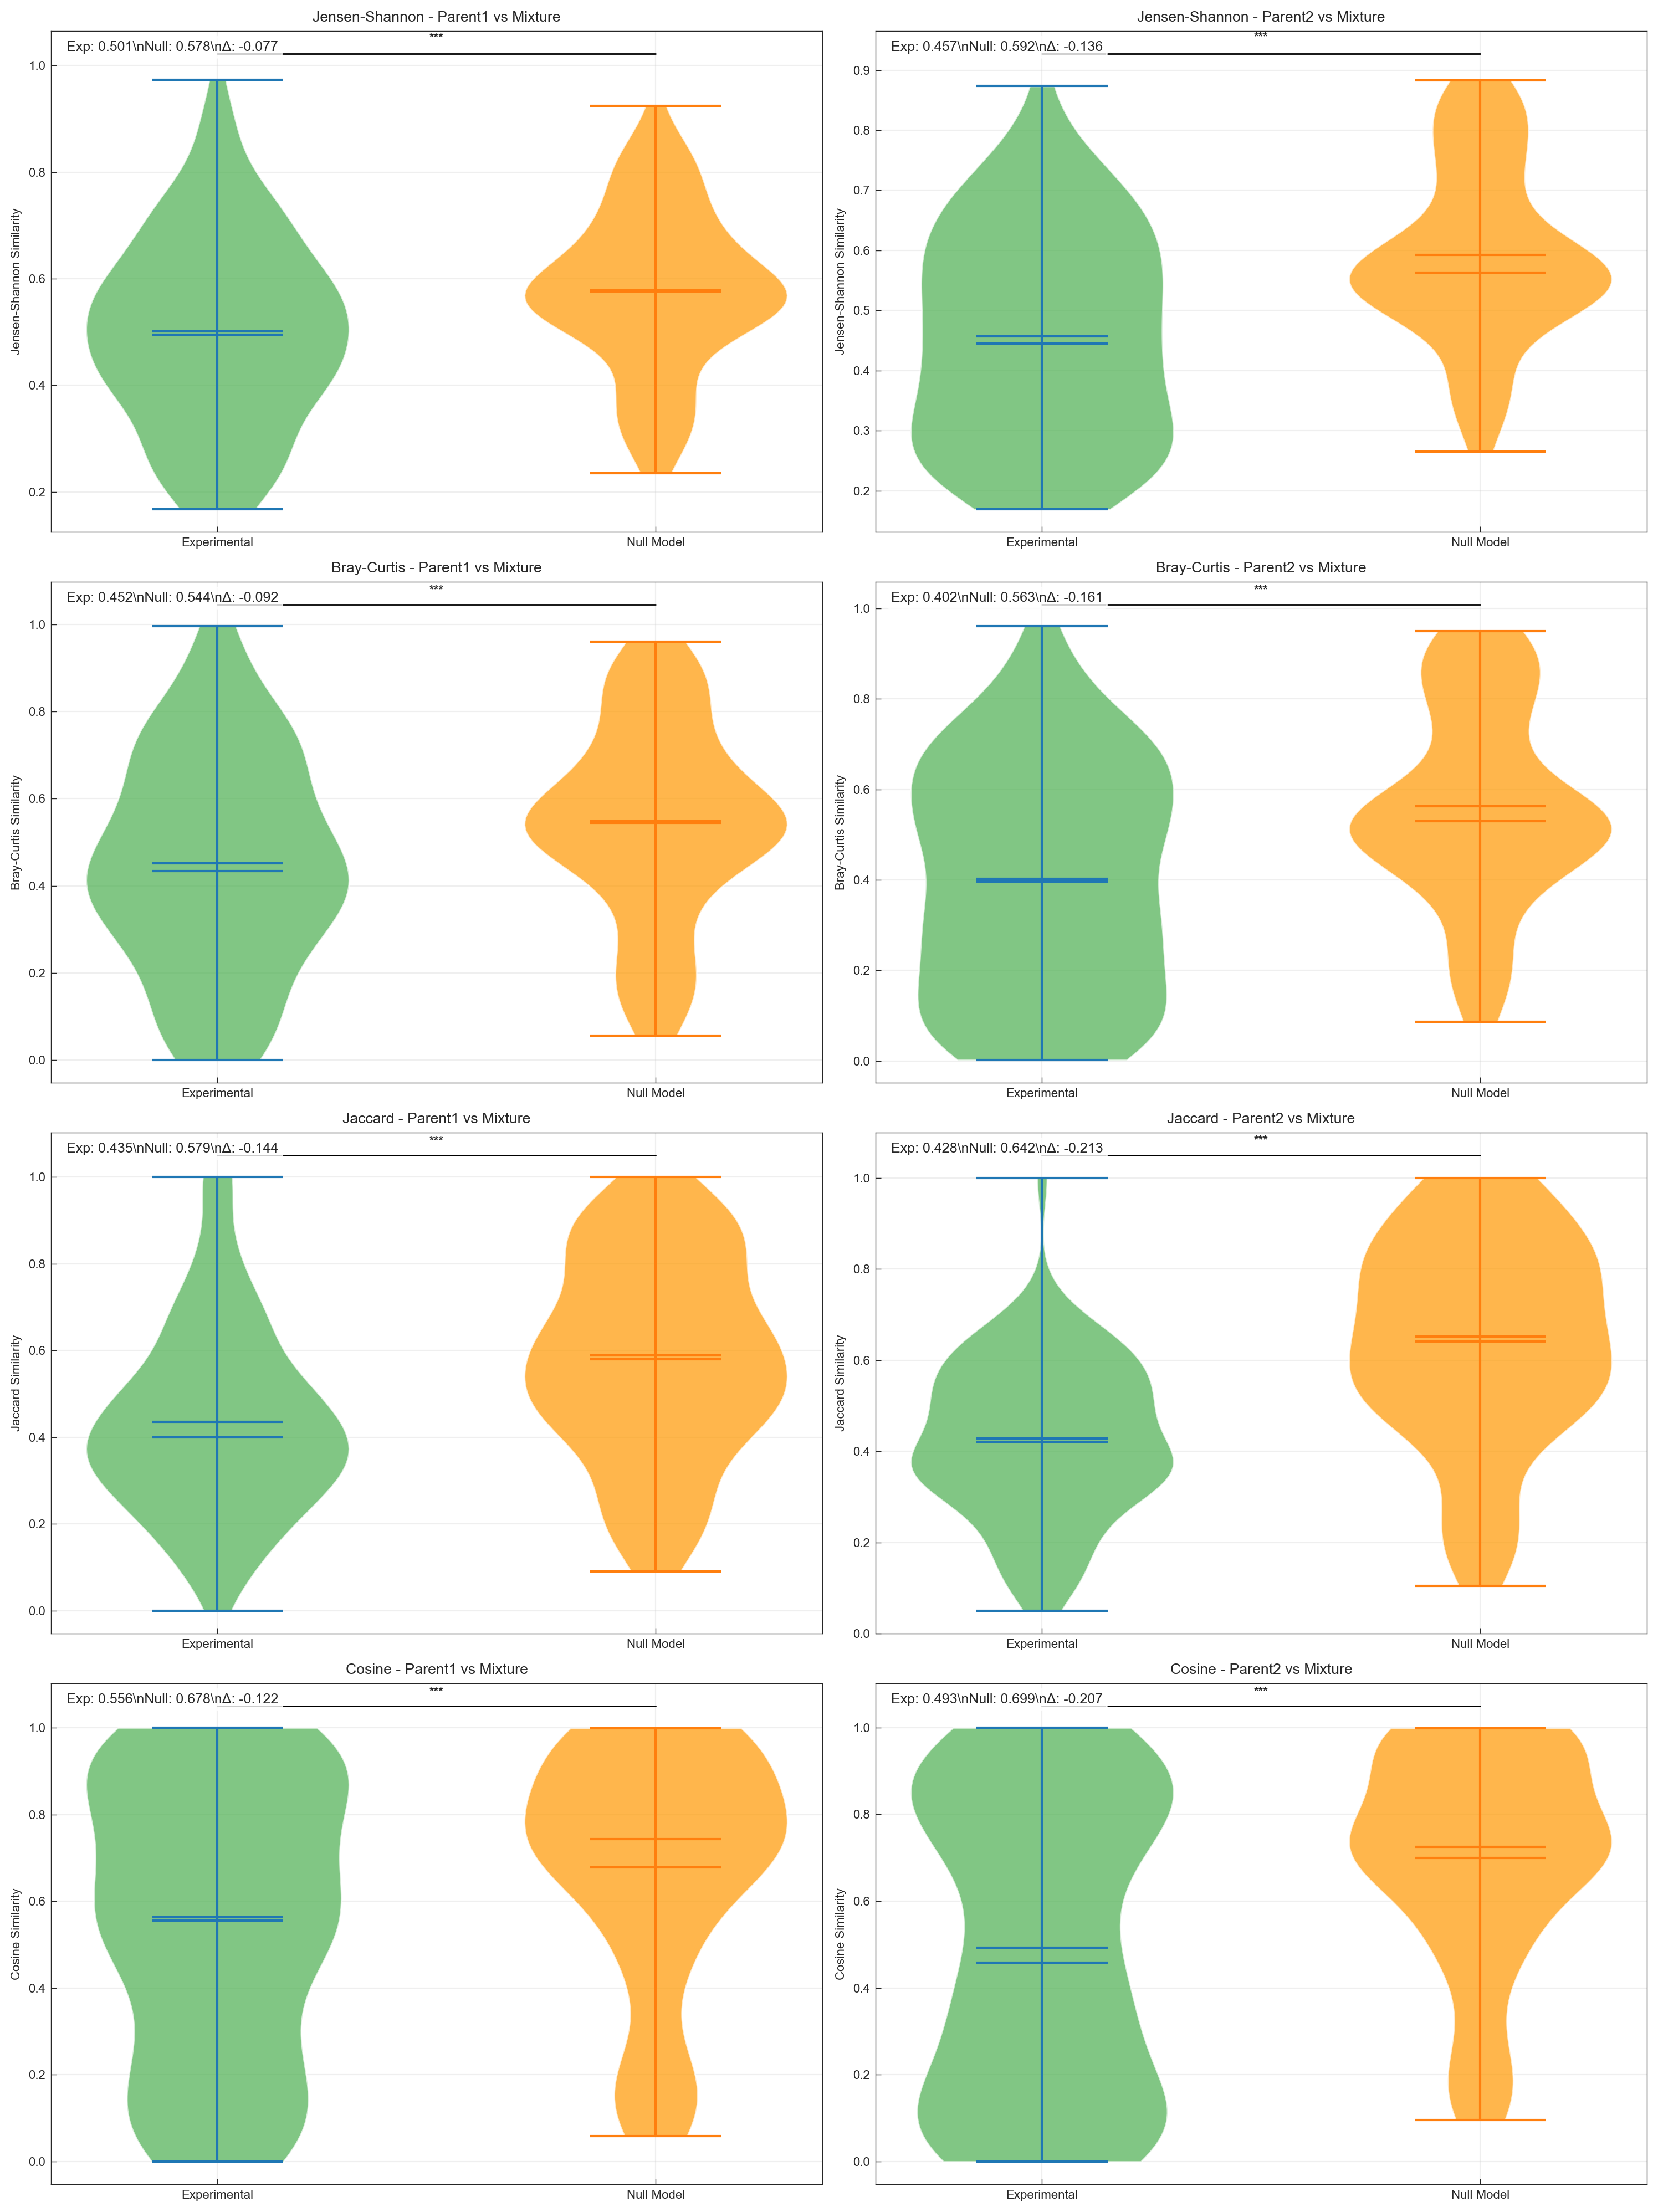


Similarity analysis complete!
Results saved to Figure/ directory


In [19]:
# =============================================================================
# EXECUTE COMPLETE SIMILARITY ANALYSIS
# =============================================================================

# Run the complete similarity analysis pipeline
print("Executing complete similarity analysis...")
print("This will:")
print("1. Compare experimental vs null model similarities")
print("2. Analyze all nutrient conditions (LN_12, MN_12, HN_12)")
print("3. Calculate multiple similarity metrics (Jensen-Shannon, Bray-Curtis, Jaccard, Cosine)")
print("4. Use OD-weighted null models with fieldOD7 preference")
print("5. Generate comprehensive comparison plots")
print("6. Save results to Figure/ directory")
print()

# Execute the analysis
results, fig = run_complete_similarity_analysis()

Starting comprehensive similarity analysis for ALL available nutrients...
This will analyze all nutrients found in Syn_Coal_IDX and all similarity metrics.

COMPREHENSIVE SIMILARITY ANALYSIS FOR ALL NUTRIENTS AND METRICS
Available nutrient conditions in Syn_Coal_IDX:
  - LN_6: 26 samples
  - LN_12: 52 samples
  - LN_24: 12 samples
  - MN_6: 27 samples
  - MN_12: 47 samples
  - MN_24: 9 samples
  - HN_6: 27 samples
  - HN_12: 52 samples
  - HN_24: 11 samples

Will analyze 4 similarity metrics:
  - Jensen-Shannon
  - Bray-Curtis
  - Jaccard
  - Cosine

Will analyze 3 comparison types:
  - Parent1 vs Mixture
  - Parent2 vs Mixture
  - Parent1 vs Parent2


PROCESSING: LN_6
Samples to process: 26
  Progress: 1/26 samples processed
  Progress: 21/26 samples processed

SUMMARY FOR LN_6:
  Successfully processed: 26 samples
  Failed samples: 0 samples
  Similarity Statistics (Experimental vs Null Model):
    Jensen-Shannon:
      Parent1 vs Mixture: Exp=0.518, Null=0.577, Δ=-0.060 (n=26)
     

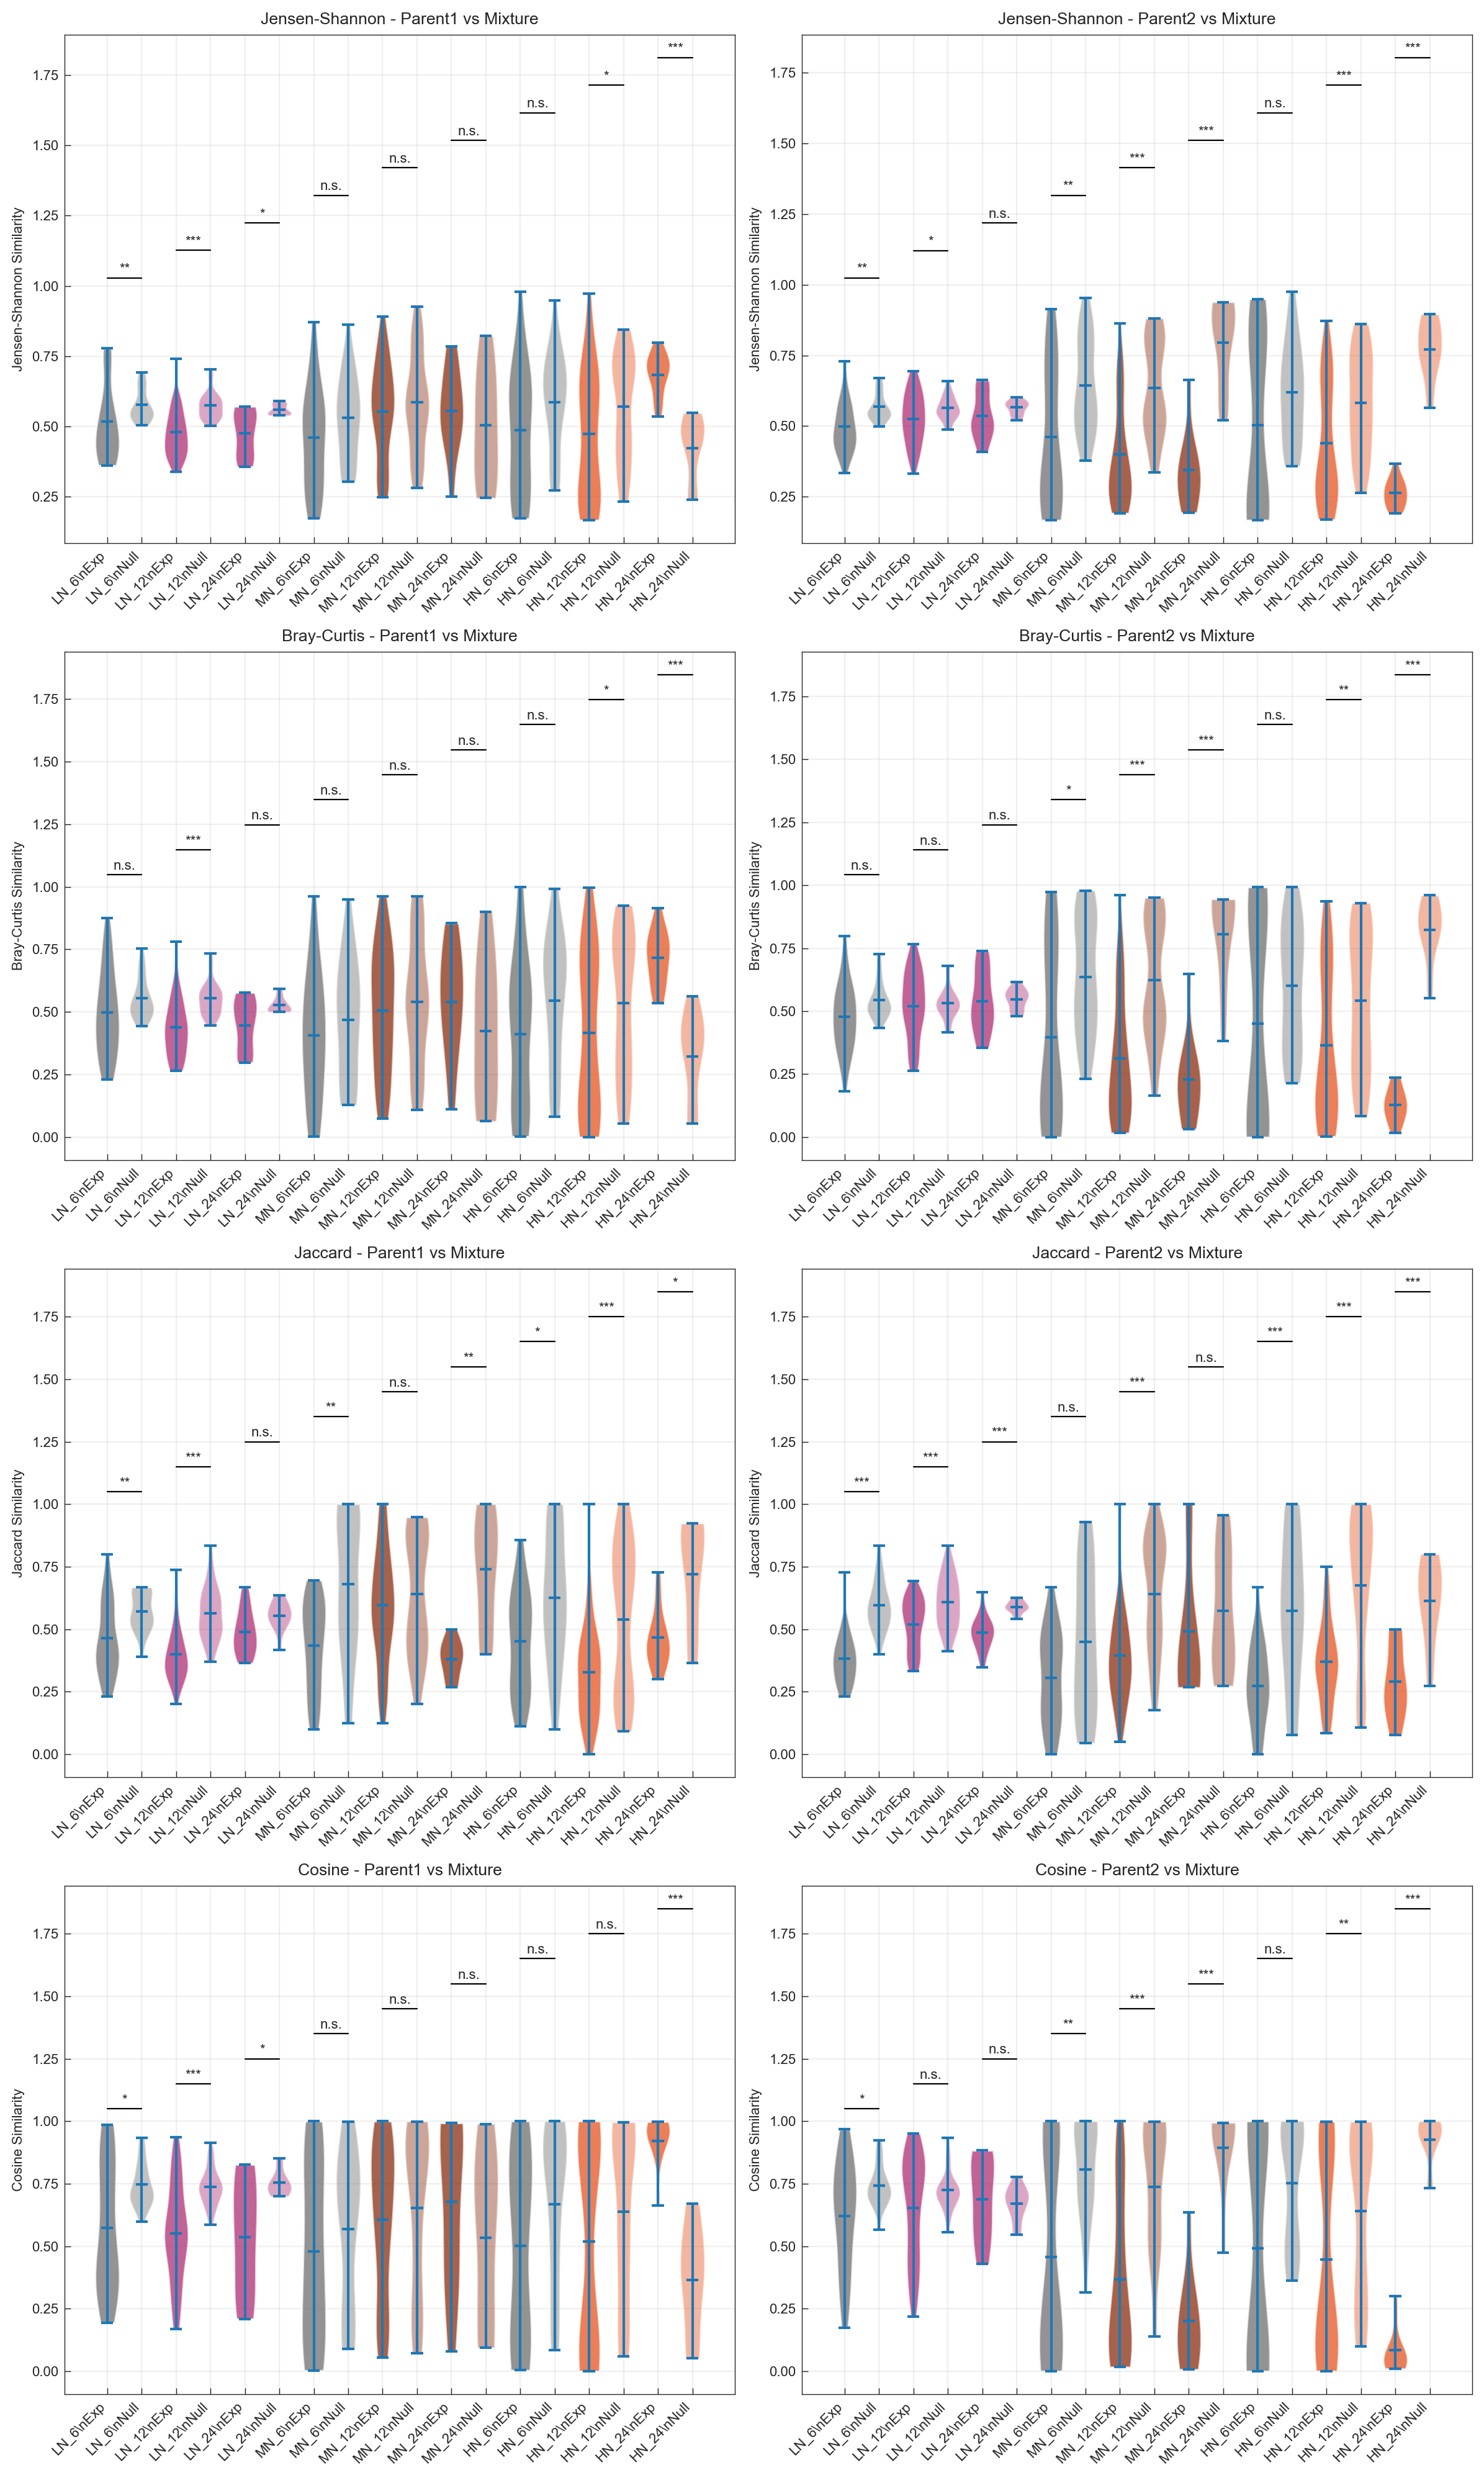


ANALYSIS COMPLETE!
Results stored in 'comprehensive_results' variable
Plots saved to Figure/ directory
Available nutrients analyzed: ['LN_6', 'LN_12', 'LN_24', 'MN_6', 'MN_12', 'MN_24', 'HN_6', 'HN_12', 'HN_24']


In [20]:
# =============================================================================
# COMPREHENSIVE ANALYSIS: ALL NUTRIENTS AND SIMILARITY METRICS
# =============================================================================

def run_comprehensive_similarity_analysis_all_nutrients():
    """
    Run similarity analysis for ALL available nutrient conditions and metrics.
    This function will automatically detect all available nutrients and run 
    comprehensive analysis for each one.
    """
    print("=" * 80)
    print("COMPREHENSIVE SIMILARITY ANALYSIS FOR ALL NUTRIENTS AND METRICS")
    print("=" * 80)
    
    # First, let's see what nutrient conditions are available
    print("Available nutrient conditions in Syn_Coal_IDX:")
    available_nutrients = list(Syn_Coal_IDX.keys())
    for nutrient in available_nutrients:
        sample_count = len(Syn_Coal_IDX[nutrient])
        print(f"  - {nutrient}: {sample_count} samples")
    print()
    
    # Define all similarity metrics
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc', 
        'Jaccard': 'jaccard',
        'Cosine': 'cosine'
    }
    
    # Define comparison types
    comparison_types = {
        'Parent1 vs Mixture': 'c1_mix',
        'Parent2 vs Mixture': 'c2_mix',
        'Parent1 vs Parent2': 'c1_c2'
    }
    
    print(f"Will analyze {len(similarity_metrics)} similarity metrics:")
    for metric_name in similarity_metrics.keys():
        print(f"  - {metric_name}")
    print()
    
    print(f"Will analyze {len(comparison_types)} comparison types:")
    for comp_name in comparison_types.keys():
        print(f"  - {comp_name}")
    print()
    
    # Store all results
    comprehensive_results = {}
    
    # Process each nutrient condition
    for nutrient_condition in available_nutrients:
        print(f"\n{'='*60}")
        print(f"PROCESSING: {nutrient_condition}")
        print(f"{'='*60}")
        
        IDX_list = Syn_Coal_IDX[nutrient_condition]
        print(f"Samples to process: {len(IDX_list)}")
        
        # Initialize results for this nutrient
        nutrient_results = {
            'experimental_similarities': {
                metric_code: {comp_code: [] for comp_code in comparison_types.values()} 
                for metric_code in similarity_metrics.values()
            },
            'null_model_similarities': {
                metric_code: {comp_code: [] for comp_code in comparison_types.values()} 
                for metric_code in similarity_metrics.values()
            },
            'od_info_list': [],
            'processed_samples': 0,
            'failed_samples': 0
        }
        
        # Process each sample
        for i, mixture_sample_idx in enumerate(IDX_list):
            if i % 20 == 0:
                print(f"  Progress: {i+1}/{len(IDX_list)} samples processed")
            
            try:
                # Get parent sample information
                coal_row = Coalescence_data[Coalescence_data['SampleIDX'] == mixture_sample_idx]
                if len(coal_row) == 0:
                    continue
                
                sample_idx_1 = coal_row.iloc[0]['SampleIDX_Sub1']
                sample_idx_2 = coal_row.iloc[0]['SampleIDX_Sub2']
                
                # Get composition data
                seq_row_1 = Processed_sequences_synthetic[Processed_sequences_synthetic['SampleIDX'] == sample_idx_1]
                seq_row_2 = Processed_sequences_synthetic[Processed_sequences_synthetic['SampleIDX'] == sample_idx_2]
                seq_row_mix = Processed_sequences_synthetic[Processed_sequences_synthetic['SampleIDX'] == mixture_sample_idx]
                
                if len(seq_row_1) == 0 or len(seq_row_2) == 0 or len(seq_row_mix) == 0:
                    continue
                
                # Extract and process composition vectors
                c_1 = np.array(seq_row_1.iloc[0, 1:].values, dtype=float)
                c_2 = np.array(seq_row_2.iloc[0, 1:].values, dtype=float)
                c_mix = np.array(seq_row_mix.iloc[0, 1:].values, dtype=float)
                
                # Filter small values and normalize
                c_1 = c_1 * (c_1 > 1e-4)
                c_2 = c_2 * (c_2 > 1e-4)
                c_mix = c_mix * (c_mix > 1e-4)
                
                c_1 = c_1 / (np.sum(c_1) + 1e-9)
                c_2 = c_2 / (np.sum(c_2) + 1e-9)
                c_mix = c_mix / (np.sum(c_mix) + 1e-9)
                
                species_num = len(c_1)
                
                # Calculate experimental similarities
                exp_similarities = calculate_all_similarities(c_1, c_2, c_mix)
                
                # Generate null model with OD weighting
                null_mixtures, od_info = generate_od_weighted_null_model_advanced(
                    c_1, c_2, sample_idx_1, sample_idx_2, species_num, n_replicates=30
                )
                
                # Calculate null model similarities
                null_sim_aggregated = {}
                for metric_code in similarity_metrics.values():
                    for comp_code in comparison_types.values():
                        null_sim_aggregated[f"{metric_code}_{comp_code}"] = []
                
                for null_mix in null_mixtures:
                    null_sim = calculate_all_similarities(c_1, c_2, null_mix)
                    for key, value in null_sim.items():
                        if key in null_sim_aggregated:
                            null_sim_aggregated[key].append(value)
                
                # Store results
                for metric_code in similarity_metrics.values():
                    for comp_code in comparison_types.values():
                        key = f"{metric_code}_{comp_code}"
                        
                        # Store experimental result
                        if key in exp_similarities:
                            nutrient_results['experimental_similarities'][metric_code][comp_code].append(
                                exp_similarities[key]
                            )
                        
                        # Store average null model result
                        if key in null_sim_aggregated and null_sim_aggregated[key]:
                            avg_null_sim = np.mean(null_sim_aggregated[key])
                            nutrient_results['null_model_similarities'][metric_code][comp_code].append(
                                avg_null_sim
                            )
                
                # Store OD info
                nutrient_results['od_info_list'].append(od_info)
                nutrient_results['processed_samples'] += 1
                
            except Exception as e:
                nutrient_results['failed_samples'] += 1
                if i < 5:  # Only print first few errors to avoid spam
                    print(f"    Error processing sample {mixture_sample_idx}: {e}")
        
        # Store results for this nutrient
        comprehensive_results[nutrient_condition] = nutrient_results
        
        # Print summary for this nutrient
        print(f"\nSUMMARY FOR {nutrient_condition}:")
        print(f"  Successfully processed: {nutrient_results['processed_samples']} samples")
        print(f"  Failed samples: {nutrient_results['failed_samples']} samples")
        
        # Print similarity statistics
        print("  Similarity Statistics (Experimental vs Null Model):")
        for metric_name, metric_code in similarity_metrics.items():
            print(f"    {metric_name}:")
            for comp_name, comp_code in comparison_types.items():
                exp_data = nutrient_results['experimental_similarities'][metric_code][comp_code]
                null_data = nutrient_results['null_model_similarities'][metric_code][comp_code]
                
                if exp_data and null_data and len(exp_data) == len(null_data):
                    exp_mean = np.mean(exp_data)
                    null_mean = np.mean(null_data)
                    difference = exp_mean - null_mean
                    
                    print(f"      {comp_name}: Exp={exp_mean:.3f}, Null={null_mean:.3f}, Δ={difference:.3f} (n={len(exp_data)})")
    
    return comprehensive_results


def create_comprehensive_similarity_plots(results_dict, save_figures=True):
    """
    Create comprehensive plots for all nutrients and similarity metrics.
    """
    import matplotlib.pyplot as plt
    from scipy import stats
    
    # Define colors for nutrients
    nutrient_colors = {
        'LN_12': '#A7216A',   # Low Nitrogen - magenta
        'LN_24': '#A7216A',   # Low Nitrogen 24h - magenta
        'MN_12': '#802000',   # Medium Nitrogen - dark red  
        'MN_24': '#802000',   # Medium Nitrogen 24h - dark red
        'HN_12': '#E24912',   # High Nitrogen - orange-red
        'HN_24': '#E24912'    # High Nitrogen 24h - orange-red
    }
    
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc',
        'Jaccard': 'jaccard', 
        'Cosine': 'cosine'
    }
    
    comparison_types = {
        'Parent1 vs Mixture': 'c1_mix',
        'Parent2 vs Mixture': 'c2_mix'
    }
    
    # Get available nutrients from results
    available_nutrients = list(results_dict.keys())
    
    # Create figure with subplots
    n_metrics = len(similarity_metrics)
    n_comparisons = len(comparison_types)
    
    fig, axes = plt.subplots(n_metrics, n_comparisons, 
                            figsize=(6*n_comparisons, 5*n_metrics), 
                            facecolor='white')
    
    if n_metrics == 1:
        axes = axes.reshape(1, -1)
    if n_comparisons == 1:
        axes = axes.reshape(-1, 1)
    
    print(f"Creating comprehensive plots for {len(available_nutrients)} nutrients...")
    
    for i, (metric_name, metric_code) in enumerate(similarity_metrics.items()):
        for j, (comp_name, comp_code) in enumerate(comparison_types.items()):
            ax = axes[i, j]
            
            # Collect data from all nutrients
            plot_data = []
            plot_labels = []
            plot_colors = []
            
            for nutrient in available_nutrients:
                if nutrient in results_dict:
                    exp_data = results_dict[nutrient]['experimental_similarities'][metric_code][comp_code]
                    null_data = results_dict[nutrient]['null_model_similarities'][metric_code][comp_code]
                    
                    if exp_data and null_data and len(exp_data) > 5:  # Minimum 5 samples
                        plot_data.extend([exp_data, null_data])
                        plot_labels.extend([f'{nutrient}\\nExp', f'{nutrient}\\nNull'])
                        
                        # Get color for this nutrient
                        base_color = nutrient_colors.get(nutrient, '#666666')
                        plot_colors.extend([base_color, base_color])
            
            if plot_data:
                # Create violin plot
                parts = ax.violinplot(plot_data, range(1, len(plot_data)+1), 
                                    widths=0.7, showmeans=True, showmedians=False)
                
                # Color the violins
                for k, pc in enumerate(parts['bodies']):
                    color = plot_colors[k] if k < len(plot_colors) else '#666666'
                    alpha = 0.7 if k % 2 == 0 else 0.4  # Experimental vs Null
                    pc.set_facecolor(color)
                    pc.set_alpha(alpha)
                
                # Add statistical tests between exp and null for each nutrient
                y_max = max([max(data) for data in plot_data])
                y_pos = y_max + 0.05 * y_max
                
                for k in range(0, len(plot_data), 2):  # Every pair (exp, null)
                    if k+1 < len(plot_data):
                        exp_data = plot_data[k]
                        null_data = plot_data[k+1]
                        
                        # Statistical test
                        try:
                            statistic, p_value = stats.mannwhitneyu(exp_data, null_data, 
                                                                   alternative='two-sided')
                            
                            # Significance stars
                            if p_value < 0.001:
                                sig_text = '***'
                            elif p_value < 0.01:
                                sig_text = '**'
                            elif p_value < 0.05:
                                sig_text = '*'
                            else:
                                sig_text = 'n.s.'
                            
                            # Draw significance line
                            x1, x2 = k+1, k+2
                            ax.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=0.8)
                            ax.text((x1+x2)/2, y_pos + 0.01*y_max, sig_text, 
                                   ha='center', va='bottom', fontsize=8)
                            
                            y_pos += 0.1 * y_max  # Offset for next pair
                            
                        except Exception as e:
                            continue
                
                # Formatting
                ax.set_xticks(range(1, len(plot_labels)+1))
                ax.set_xticklabels(plot_labels, rotation=45, ha='right')
                ax.set_ylabel(f'{metric_name} Similarity')
                ax.set_title(f'{metric_name} - {comp_name}')
                ax.grid(True, alpha=0.3)
                
            else:
                ax.text(0.5, 0.5, 'No Data Available', ha='center', va='center',
                       transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{metric_name} - {comp_name}')
    
    plt.tight_layout()
    
    if save_figures:
        plt.savefig('Figure/Comprehensive_Similarity_Analysis_All_Nutrients.svg', 
                   bbox_inches='tight', dpi=300)
        plt.savefig('Figure/Comprehensive_Similarity_Analysis_All_Nutrients.png', 
                   bbox_inches='tight', dpi=300)
        print("Figures saved to Figure/ directory")
    
    plt.show()
    return fig


# =============================================================================
# EXECUTE COMPREHENSIVE ANALYSIS FOR ALL NUTRIENTS
# =============================================================================

print("Starting comprehensive similarity analysis for ALL available nutrients...")
print("This will analyze all nutrients found in Syn_Coal_IDX and all similarity metrics.")
print()

# Run the comprehensive analysis
comprehensive_results = run_comprehensive_similarity_analysis_all_nutrients()

print("\n" + "="*80)
print("CREATING COMPREHENSIVE PLOTS...")
print("="*80)

# Create comprehensive plots
comprehensive_fig = create_comprehensive_similarity_plots(comprehensive_results, save_figures=True)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("Results stored in 'comprehensive_results' variable")
print("Plots saved to Figure/ directory")
print("Available nutrients analyzed:", list(comprehensive_results.keys()))

Analyzing similarity deviations from neutral point (0.5)...
This will show whether experimental similarities are more or less than random chance.

SIMILARITY DEVIATION FROM NEUTRAL POINT (0.5) ANALYSIS
\n============================================================
NUTRIENT CONDITION: LN_6
Jensen-Shannon - Parent1 vs Mixture:
  Experimental deviation: +0.0175 ± 0.1343
  Null model deviation:   +0.0775 ± 0.0560
  Difference (Exp - Null): -0.0600
  Interpretation: Experimental data is MORE similar than random

Jensen-Shannon - Parent2 vs Mixture:
  Experimental deviation: -0.0023 ± 0.0906
  Null model deviation:   +0.0700 ± 0.0491
  Difference (Exp - Null): -0.0723
  Interpretation: Experimental data is LESS similar than random

Bray-Curtis - Parent1 vs Mixture:
  Experimental deviation: -0.0021 ± 0.1762
  Null model deviation:   +0.0553 ± 0.0814
  Difference (Exp - Null): -0.0573
  Interpretation: Experimental data is LESS similar than random

Bray-Curtis - Parent2 vs Mixture:
  Experime

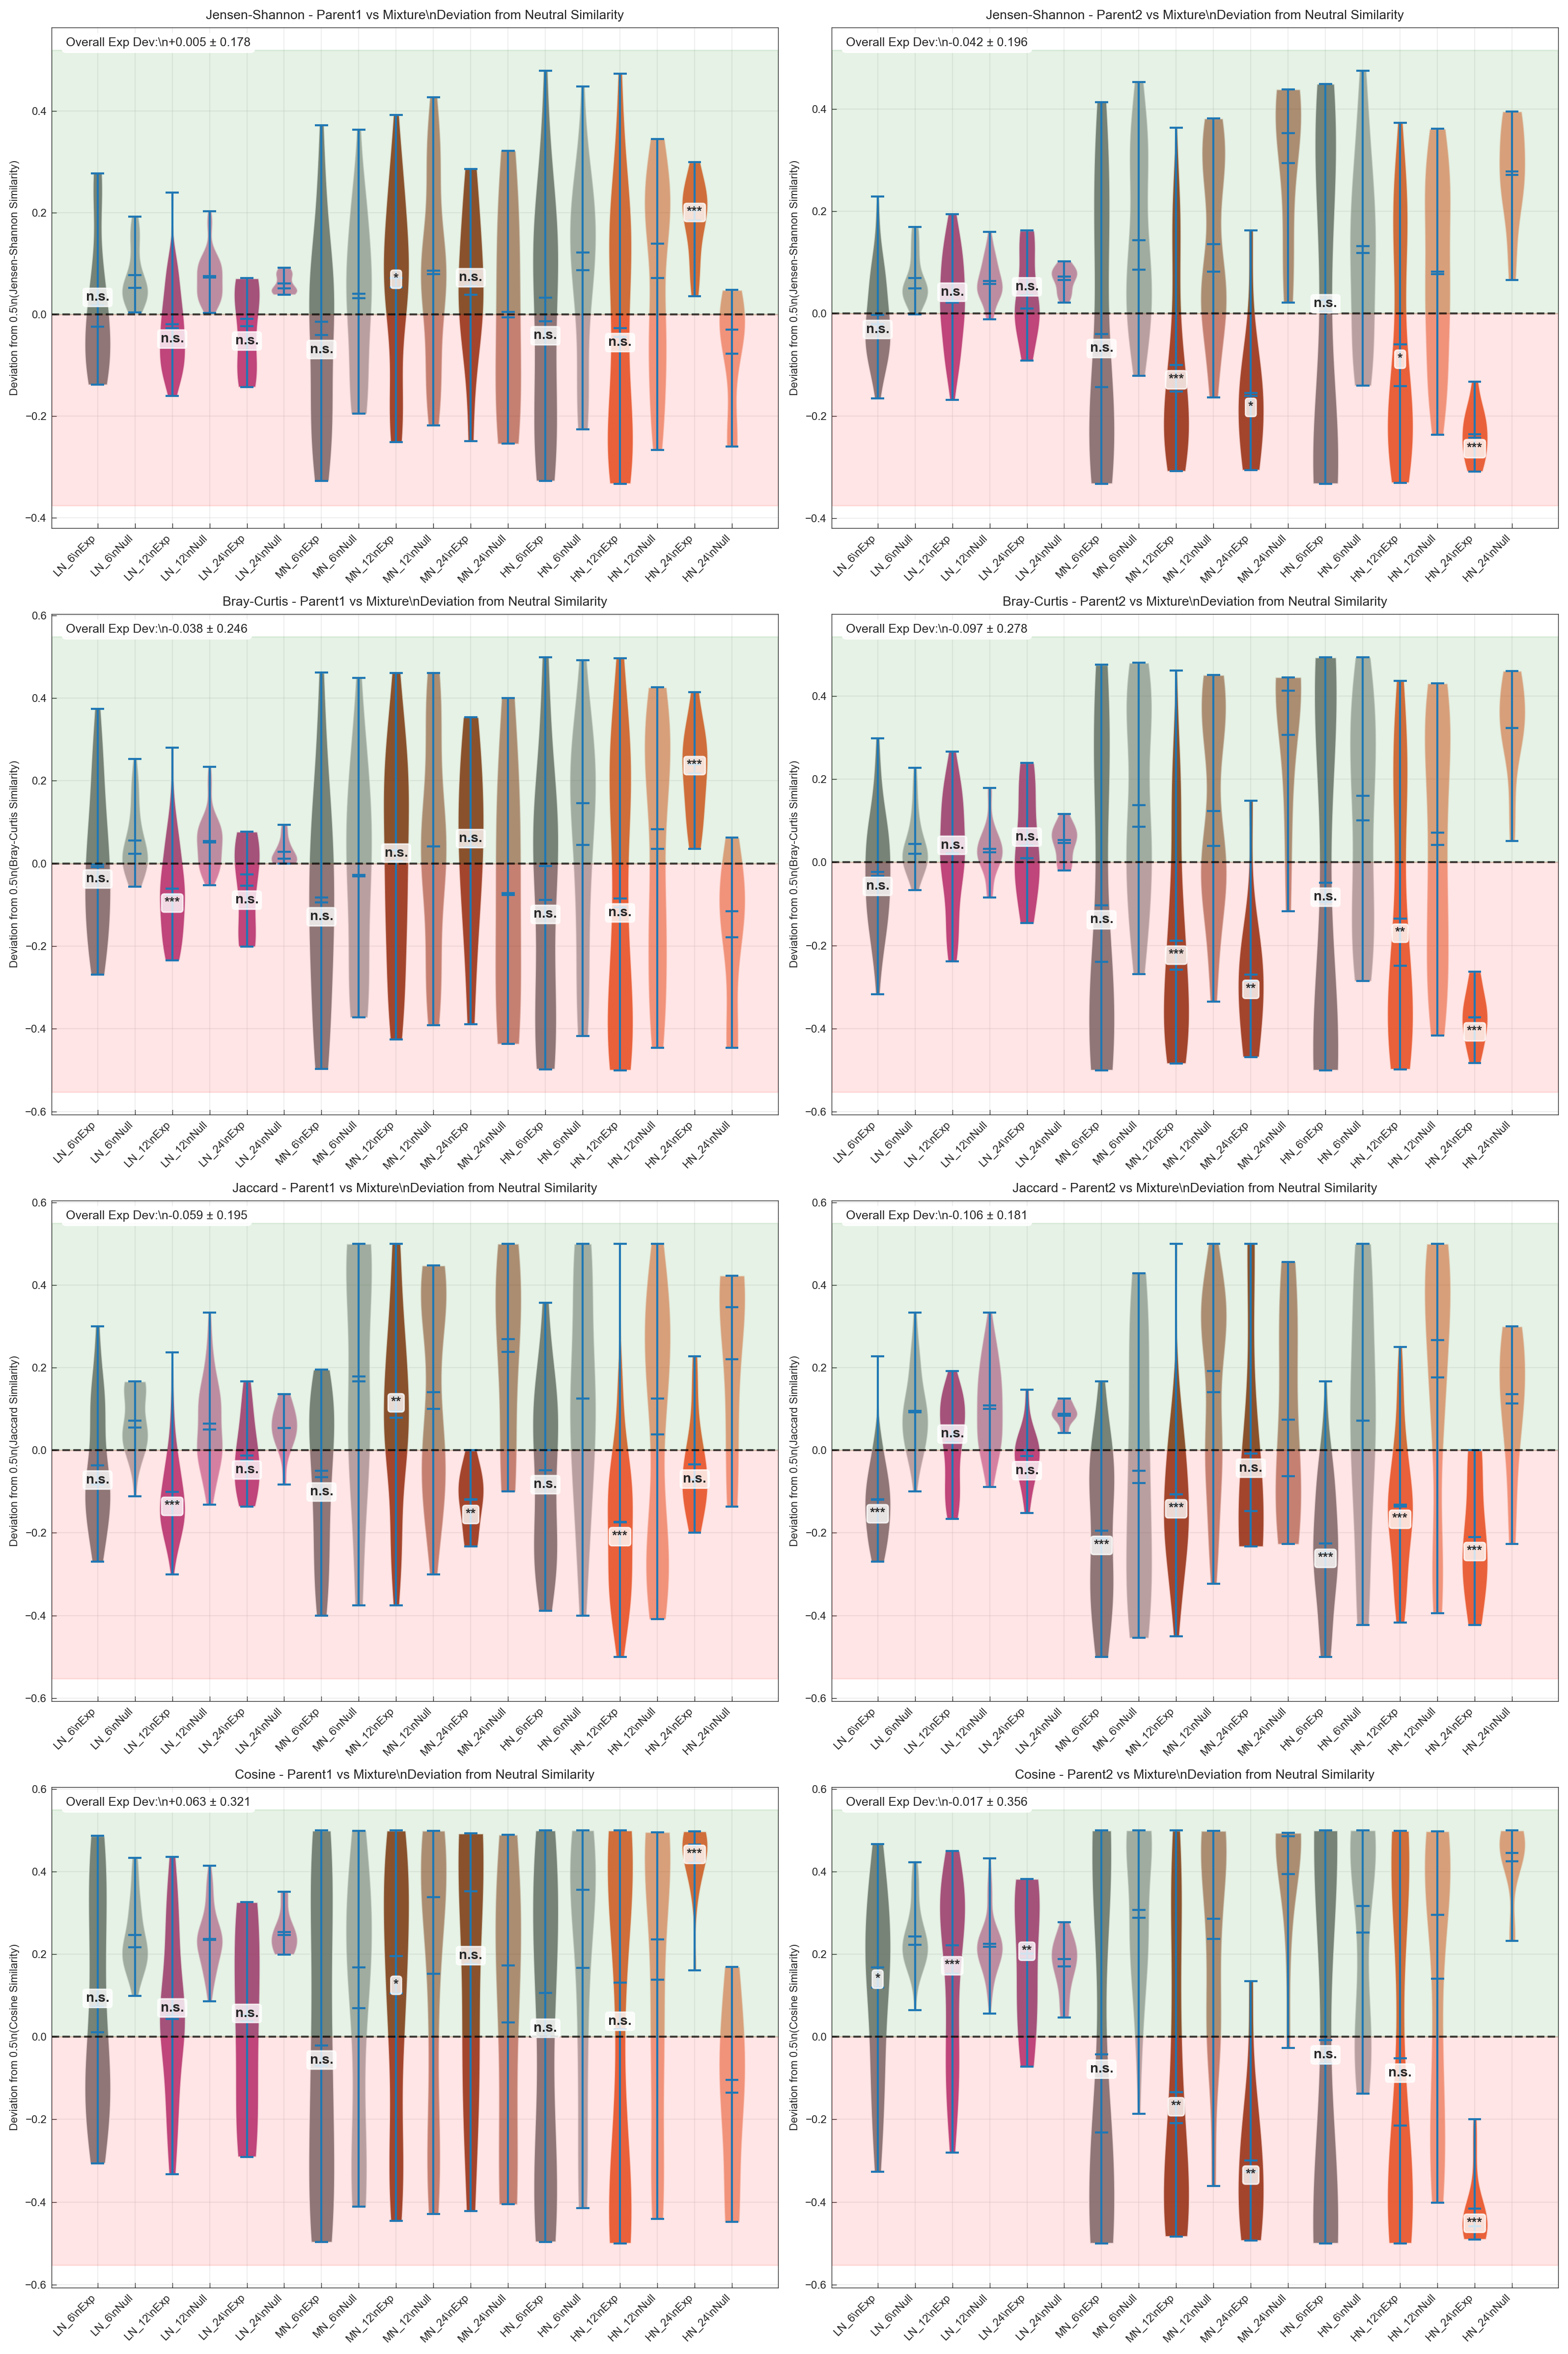

\n================================================================================
CREATING SUMMARY TABLE...
\n====================================================================================================
SUMMARY TABLE: SIMILARITY DEVIATIONS FROM NEUTRAL POINT
Nutrient         Metric         Comparison Exp_Mean_Deviation Exp_Std_Deviation Null_Mean_Deviation Null_Std_Deviation Difference Interpretation  N_Samples
    LN_6 Jensen-Shannon Parent1 vs Mixture            +0.0175            0.1343             +0.0775             0.0560    -0.0600        Neutral         26
    LN_6 Jensen-Shannon Parent2 vs Mixture            -0.0023            0.0906             +0.0700             0.0491    -0.0723        Neutral         26
    LN_6    Bray-Curtis Parent1 vs Mixture            -0.0021            0.1762             +0.0553             0.0814    -0.0573        Neutral         26
    LN_6    Bray-Curtis Parent2 vs Mixture            -0.0228            0.1393             +0.0442         

In [21]:
# =============================================================================
# SIMILARITY DEVIATION FROM 0.5 (NEUTRAL SIMILARITY) ANALYSIS
# =============================================================================

def calculate_deviation_from_neutral(similarity_value, neutral_point=0.5):
    """
    Calculate deviation from neutral similarity point (0.5).
    
    Parameters:
    - similarity_value: The observed similarity value
    - neutral_point: The neutral/random similarity point (default 0.5)
    
    Returns:
    - deviation: Signed deviation from neutral (positive = more similar than random)
    """
    return similarity_value - neutral_point


def analyze_similarity_deviations(results_dict, neutral_point=0.5):
    """
    Analyze how much similarities deviate from the neutral point (0.5).
    """
    print("=" * 80)
    print(f"SIMILARITY DEVIATION FROM NEUTRAL POINT ({neutral_point}) ANALYSIS")
    print("=" * 80)
    
    # Define metrics and comparisons
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc',
        'Jaccard': 'jaccard',
        'Cosine': 'cosine'
    }
    
    comparison_types = {
        'Parent1 vs Mixture': 'c1_mix',
        'Parent2 vs Mixture': 'c2_mix'
    }
    
    # Initialize deviation results
    deviation_results = {}
    
    # Process each nutrient condition
    for nutrient in results_dict.keys():
        print(f"\\n{'='*60}")
        print(f"NUTRIENT CONDITION: {nutrient}")
        print(f"{'='*60}")
        
        deviation_results[nutrient] = {
            'experimental_deviations': {
                metric_code: {comp_code: [] for comp_code in comparison_types.values()} 
                for metric_code in similarity_metrics.values()
            },
            'null_model_deviations': {
                metric_code: {comp_code: [] for comp_code in comparison_types.values()} 
                for metric_code in similarity_metrics.values()
            }
        }
        
        # Calculate deviations for each metric and comparison
        for metric_name, metric_code in similarity_metrics.items():
            for comp_name, comp_code in comparison_types.items():
                
                # Get experimental and null model data
                exp_data = results_dict[nutrient]['experimental_similarities'][metric_code][comp_code]
                null_data = results_dict[nutrient]['null_model_similarities'][metric_code][comp_code]
                
                if exp_data and null_data:
                    # Calculate deviations from neutral point
                    exp_deviations = [calculate_deviation_from_neutral(sim, neutral_point) for sim in exp_data]
                    null_deviations = [calculate_deviation_from_neutral(sim, neutral_point) for sim in null_data]
                    
                    # Store deviations
                    deviation_results[nutrient]['experimental_deviations'][metric_code][comp_code] = exp_deviations
                    deviation_results[nutrient]['null_model_deviations'][metric_code][comp_code] = null_deviations
                    
                    # Print statistics
                    exp_mean_dev = np.mean(exp_deviations)
                    null_mean_dev = np.mean(null_deviations)
                    
                    print(f"{metric_name} - {comp_name}:")
                    print(f"  Experimental deviation: {exp_mean_dev:+.4f} ± {np.std(exp_deviations):.4f}")
                    print(f"  Null model deviation:   {null_mean_dev:+.4f} ± {np.std(null_deviations):.4f}")
                    print(f"  Difference (Exp - Null): {exp_mean_dev - null_mean_dev:+.4f}")
                    
                    # Interpretation
                    if exp_mean_dev > 0:
                        exp_interp = "MORE similar than random"
                    elif exp_mean_dev < 0:
                        exp_interp = "LESS similar than random"
                    else:
                        exp_interp = "Similar to random"
                    
                    print(f"  Interpretation: Experimental data is {exp_interp}")
                    print()
    
    return deviation_results


def plot_deviation_from_neutral(deviation_results, neutral_point=0.5, save_figures=True):
    """
    Create comprehensive plots showing deviation from neutral similarity.
    """
    import matplotlib.pyplot as plt
    from scipy import stats
    
    # Define colors for nutrients
    nutrient_colors = {
        'LN_12': '#A7216A',   # Low Nitrogen - magenta
        'LN_24': '#A7216A',   # Low Nitrogen 24h - lighter magenta
        'MN_12': '#802000',   # Medium Nitrogen - dark red  
        'MN_24': '#802000',   # Medium Nitrogen 24h - lighter red
        'HN_12': '#E24912',   # High Nitrogen - orange-red
        'HN_24': '#E24912'    # High Nitrogen 24h - lighter orange
    }
    
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc',
        'Jaccard': 'jaccard',
        'Cosine': 'cosine'
    }
    
    comparison_types = {
        'Parent1 vs Mixture': 'c1_mix',
        'Parent2 vs Mixture': 'c2_mix'
    }
    
    # Get available nutrients
    available_nutrients = list(deviation_results.keys())
    
    # Create figure with subplots
    n_metrics = len(similarity_metrics)
    n_comparisons = len(comparison_types)
    
    fig, axes = plt.subplots(n_metrics, n_comparisons, 
                            figsize=(8*n_comparisons, 6*n_metrics), 
                            facecolor='white')
    
    if n_metrics == 1:
        axes = axes.reshape(1, -1)
    if n_comparisons == 1:
        axes = axes.reshape(-1, 1)
    
    print(f"Creating deviation plots for {len(available_nutrients)} nutrients...")
    
    for i, (metric_name, metric_code) in enumerate(similarity_metrics.items()):
        for j, (comp_name, comp_code) in enumerate(comparison_types.items()):
            ax = axes[i, j]
            
            # Collect deviation data
            plot_data = []
            plot_labels = []
            plot_colors = []
            
            for nutrient in available_nutrients:
                exp_deviations = deviation_results[nutrient]['experimental_deviations'][metric_code][comp_code]
                null_deviations = deviation_results[nutrient]['null_model_deviations'][metric_code][comp_code]
                
                if exp_deviations and null_deviations and len(exp_deviations) > 5:
                    plot_data.extend([exp_deviations, null_deviations])
                    plot_labels.extend([f'{nutrient}\\nExp', f'{nutrient}\\nNull'])
                    
                    base_color = nutrient_colors.get(nutrient, '#666666')
                    plot_colors.extend([base_color, base_color])
            
            if plot_data:
                # Create violin plot
                parts = ax.violinplot(plot_data, range(1, len(plot_data)+1), 
                                    widths=0.7, showmeans=True, showmedians=True)
                
                # Color the violins
                for k, pc in enumerate(parts['bodies']):
                    color = plot_colors[k] if k < len(plot_colors) else '#666666'
                    alpha = 0.8 if k % 2 == 0 else 0.5  # Experimental vs Null
                    pc.set_facecolor(color)
                    pc.set_alpha(alpha)
                
                # Add horizontal line at zero (neutral point)
                ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, 
                          label=f'Neutral Similarity ({neutral_point})')
                
                # Add statistical tests and annotations
                y_max = max([max(data) for data in plot_data])
                y_min = min([min(data) for data in plot_data])
                y_range = y_max - y_min
                y_pos = y_max + 0.05 * y_range
                
                for k in range(0, len(plot_data), 2):  # Every pair (exp, null)
                    if k+1 < len(plot_data):
                        exp_data = plot_data[k]
                        null_data = plot_data[k+1]
                        
                        # Statistical test
                        try:
                            statistic, p_value = stats.mannwhitneyu(
                                [abs(x) for x in exp_data], 
                                [abs(x) for x in null_data], 
                                alternative='two-sided'
                            )
                            
                            # Test if experimental deviations are significantly different from zero
                            t_stat, p_value_zero = stats.ttest_1samp(exp_data, 0)
                            
                            # Significance stars for difference from zero
                            if p_value_zero < 0.001:
                                sig_text = '***'
                            elif p_value_zero < 0.01:
                                sig_text = '**'
                            elif p_value_zero < 0.05:
                                sig_text = '*'
                            else:
                                sig_text = 'n.s.'
                            
                            # Add significance annotation above experimental data
                            x_pos = k + 1
                            exp_mean = np.mean(exp_data)
                            y_text_pos = exp_mean + 0.02 * y_range if exp_mean > 0 else exp_mean - 0.02 * y_range
                            
                            ax.text(x_pos, y_text_pos, sig_text, ha='center', va='center' if exp_mean > 0 else 'top',
                                   fontsize=10, fontweight='bold', 
                                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
                            
                        except Exception as e:
                            continue
                
                # Formatting
                ax.set_xticks(range(1, len(plot_labels)+1))
                ax.set_xticklabels(plot_labels, rotation=45, ha='right')
                ax.set_ylabel(f'Deviation from {neutral_point}\\n({metric_name} Similarity)')
                ax.set_title(f'{metric_name} - {comp_name}\\nDeviation from Neutral Similarity')
                ax.grid(True, alpha=0.3)
                
                # Add color-coded regions
                ax.axhspan(0, ax.get_ylim()[1], alpha=0.1, color='green', label='More Similar than Random')
                ax.axhspan(ax.get_ylim()[0], 0, alpha=0.1, color='red', label='Less Similar than Random')
                
                # Add summary statistics
                all_exp_deviations = []
                for k in range(0, len(plot_data), 2):
                    all_exp_deviations.extend(plot_data[k])
                
                if all_exp_deviations:
                    mean_dev = np.mean(all_exp_deviations)
                    std_dev = np.std(all_exp_deviations)
                    
                    stats_text = f'Overall Exp Dev:\\n{mean_dev:+.3f} ± {std_dev:.3f}'
                    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                           va='top', ha='left', fontsize=9,
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
                
            else:
                ax.text(0.5, 0.5, 'No Data Available', ha='center', va='center',
                       transform=ax.transAxes, fontsize=12)
                ax.set_title(f'{metric_name} - {comp_name}')
    
    plt.tight_layout()
    
    if save_figures:
        plt.savefig(f'Figure/Similarity_Deviation_from_{neutral_point}_Analysis.svg', 
                   bbox_inches='tight', dpi=300)
        plt.savefig(f'Figure/Similarity_Deviation_from_{neutral_point}_Analysis.png', 
                   bbox_inches='tight', dpi=300)
        print(f"Deviation analysis figures saved to Figure/ directory")
    
    plt.show()
    return fig


def create_deviation_summary_table(deviation_results, neutral_point=0.5):
    """
    Create a summary table of deviations from neutral similarity.
    """
    import pandas as pd
    
    # Prepare data for summary table
    summary_data = []
    
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc',
        'Jaccard': 'jaccard',
        'Cosine': 'cosine'
    }
    
    comparison_types = {
        'Parent1 vs Mixture': 'c1_mix',
        'Parent2 vs Mixture': 'c2_mix'
    }
    
    for nutrient in deviation_results.keys():
        for metric_name, metric_code in similarity_metrics.items():
            for comp_name, comp_code in comparison_types.items():
                
                exp_deviations = deviation_results[nutrient]['experimental_deviations'][metric_code][comp_code]
                null_deviations = deviation_results[nutrient]['null_model_deviations'][metric_code][comp_code]
                
                if exp_deviations and null_deviations:
                    exp_mean = np.mean(exp_deviations)
                    exp_std = np.std(exp_deviations)
                    null_mean = np.mean(null_deviations)
                    null_std = np.std(null_deviations)
                    
                    # Determine interpretation
                    if abs(exp_mean) > 0.05:  # Threshold for meaningful deviation
                        if exp_mean > 0:
                            interpretation = "More similar"
                        else:
                            interpretation = "Less similar"
                    else:
                        interpretation = "Neutral"
                    
                    summary_data.append({
                        'Nutrient': nutrient,
                        'Metric': metric_name,
                        'Comparison': comp_name,
                        'Exp_Mean_Deviation': f'{exp_mean:+.4f}',
                        'Exp_Std_Deviation': f'{exp_std:.4f}',
                        'Null_Mean_Deviation': f'{null_mean:+.4f}',
                        'Null_Std_Deviation': f'{null_std:.4f}',
                        'Difference': f'{exp_mean - null_mean:+.4f}',
                        'Interpretation': interpretation,
                        'N_Samples': len(exp_deviations)
                    })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\\n" + "="*100)
    print("SUMMARY TABLE: SIMILARITY DEVIATIONS FROM NEUTRAL POINT")
    print("="*100)
    print(summary_df.to_string(index=False))
    
    return summary_df


# =============================================================================
# EXECUTE DEVIATION ANALYSIS
# =============================================================================

print("Analyzing similarity deviations from neutral point (0.5)...")
print("This will show whether experimental similarities are more or less than random chance.")
print()

# Calculate deviations from neutral point
deviation_results = analyze_similarity_deviations(comprehensive_results, neutral_point=0.5)

print("\\n" + "="*80)
print("CREATING DEVIATION PLOTS...")
print("="*80)

# Create deviation plots
deviation_fig = plot_deviation_from_neutral(deviation_results, neutral_point=0.5, save_figures=True)

print("\\n" + "="*80)
print("CREATING SUMMARY TABLE...")
print("="*80)

# Create summary table
summary_table = create_deviation_summary_table(deviation_results, neutral_point=0.5)

print("\\n" + "="*80)
print("DEVIATION ANALYSIS COMPLETE!")
print("="*80)
print("Key insights:")
print("• Positive deviations = MORE similar than random chance")
print("• Negative deviations = LESS similar than random chance") 
print("• Values near 0 = Similar to random chance")
print("• Statistical significance shown with stars (*, **, ***)")
print("\\nResults stored in 'deviation_results' and 'summary_table' variables")

Starting enhanced similarity analysis with merged parents...
This will:
1. Merge Parent1 and Parent2 data (order doesn't matter)
2. Calculate absolute deviation: |0.5 - similarity|
3. Calculate relative similarity: |(sim₁-sim₂)/(sim₁+sim₂)|
4. Create two-panel plots: Absolute (left) vs Relative (right)

CALCULATING MERGED SIMILARITY METRICS
\nProcessing LN_6...
  Jensen-Shannon:
    Merged samples: Exp=52, Null=52
    Abs deviation: Exp=0.091±0.070, Null=0.074±0.053
    Rel similarity: Exp=0.156±0.093, Null=0.028±0.022
  Bray-Curtis:
    Merged samples: Exp=52, Null=52
    Abs deviation: Exp=0.130±0.092, Null=0.063±0.066
    Rel similarity: Exp=0.248±0.147, Null=0.041±0.036
  Jaccard:
    Merged samples: Exp=52, Null=52
    Abs deviation: Exp=0.138±0.075, Null=0.096±0.075
    Rel similarity: Exp=0.182±0.162, Null=0.109±0.081
  Cosine:
    Merged samples: Exp=52, Null=52
    Abs deviation: Exp=0.222±0.129, Null=0.245±0.084
    Rel similarity: Exp=0.349±0.154, Null=0.042±0.044
\nProcessi

/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_93094/2603057682.py:302: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_93094/2603057682.py:302: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_93094/2603057682.py:305: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('Figure/Absolute_and_Relative_Similarity_Analysis.svg',
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_93094/2603057682.py:305: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.savefig('Figure/Absolute_and_Relative_Similarity_Analysis.svg',
/var/folders/ml/8vkvr85554d3lhwlyxkmt_240000gn/T/ipykernel_93094/2603057682.py:307: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.savefig('Figure/Absolute_and_Relative

Absolute and relative similarity figures saved to Figure/ directory


/Users/jysong/miniforge3/envs/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jysong/miniforge3/envs/myenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


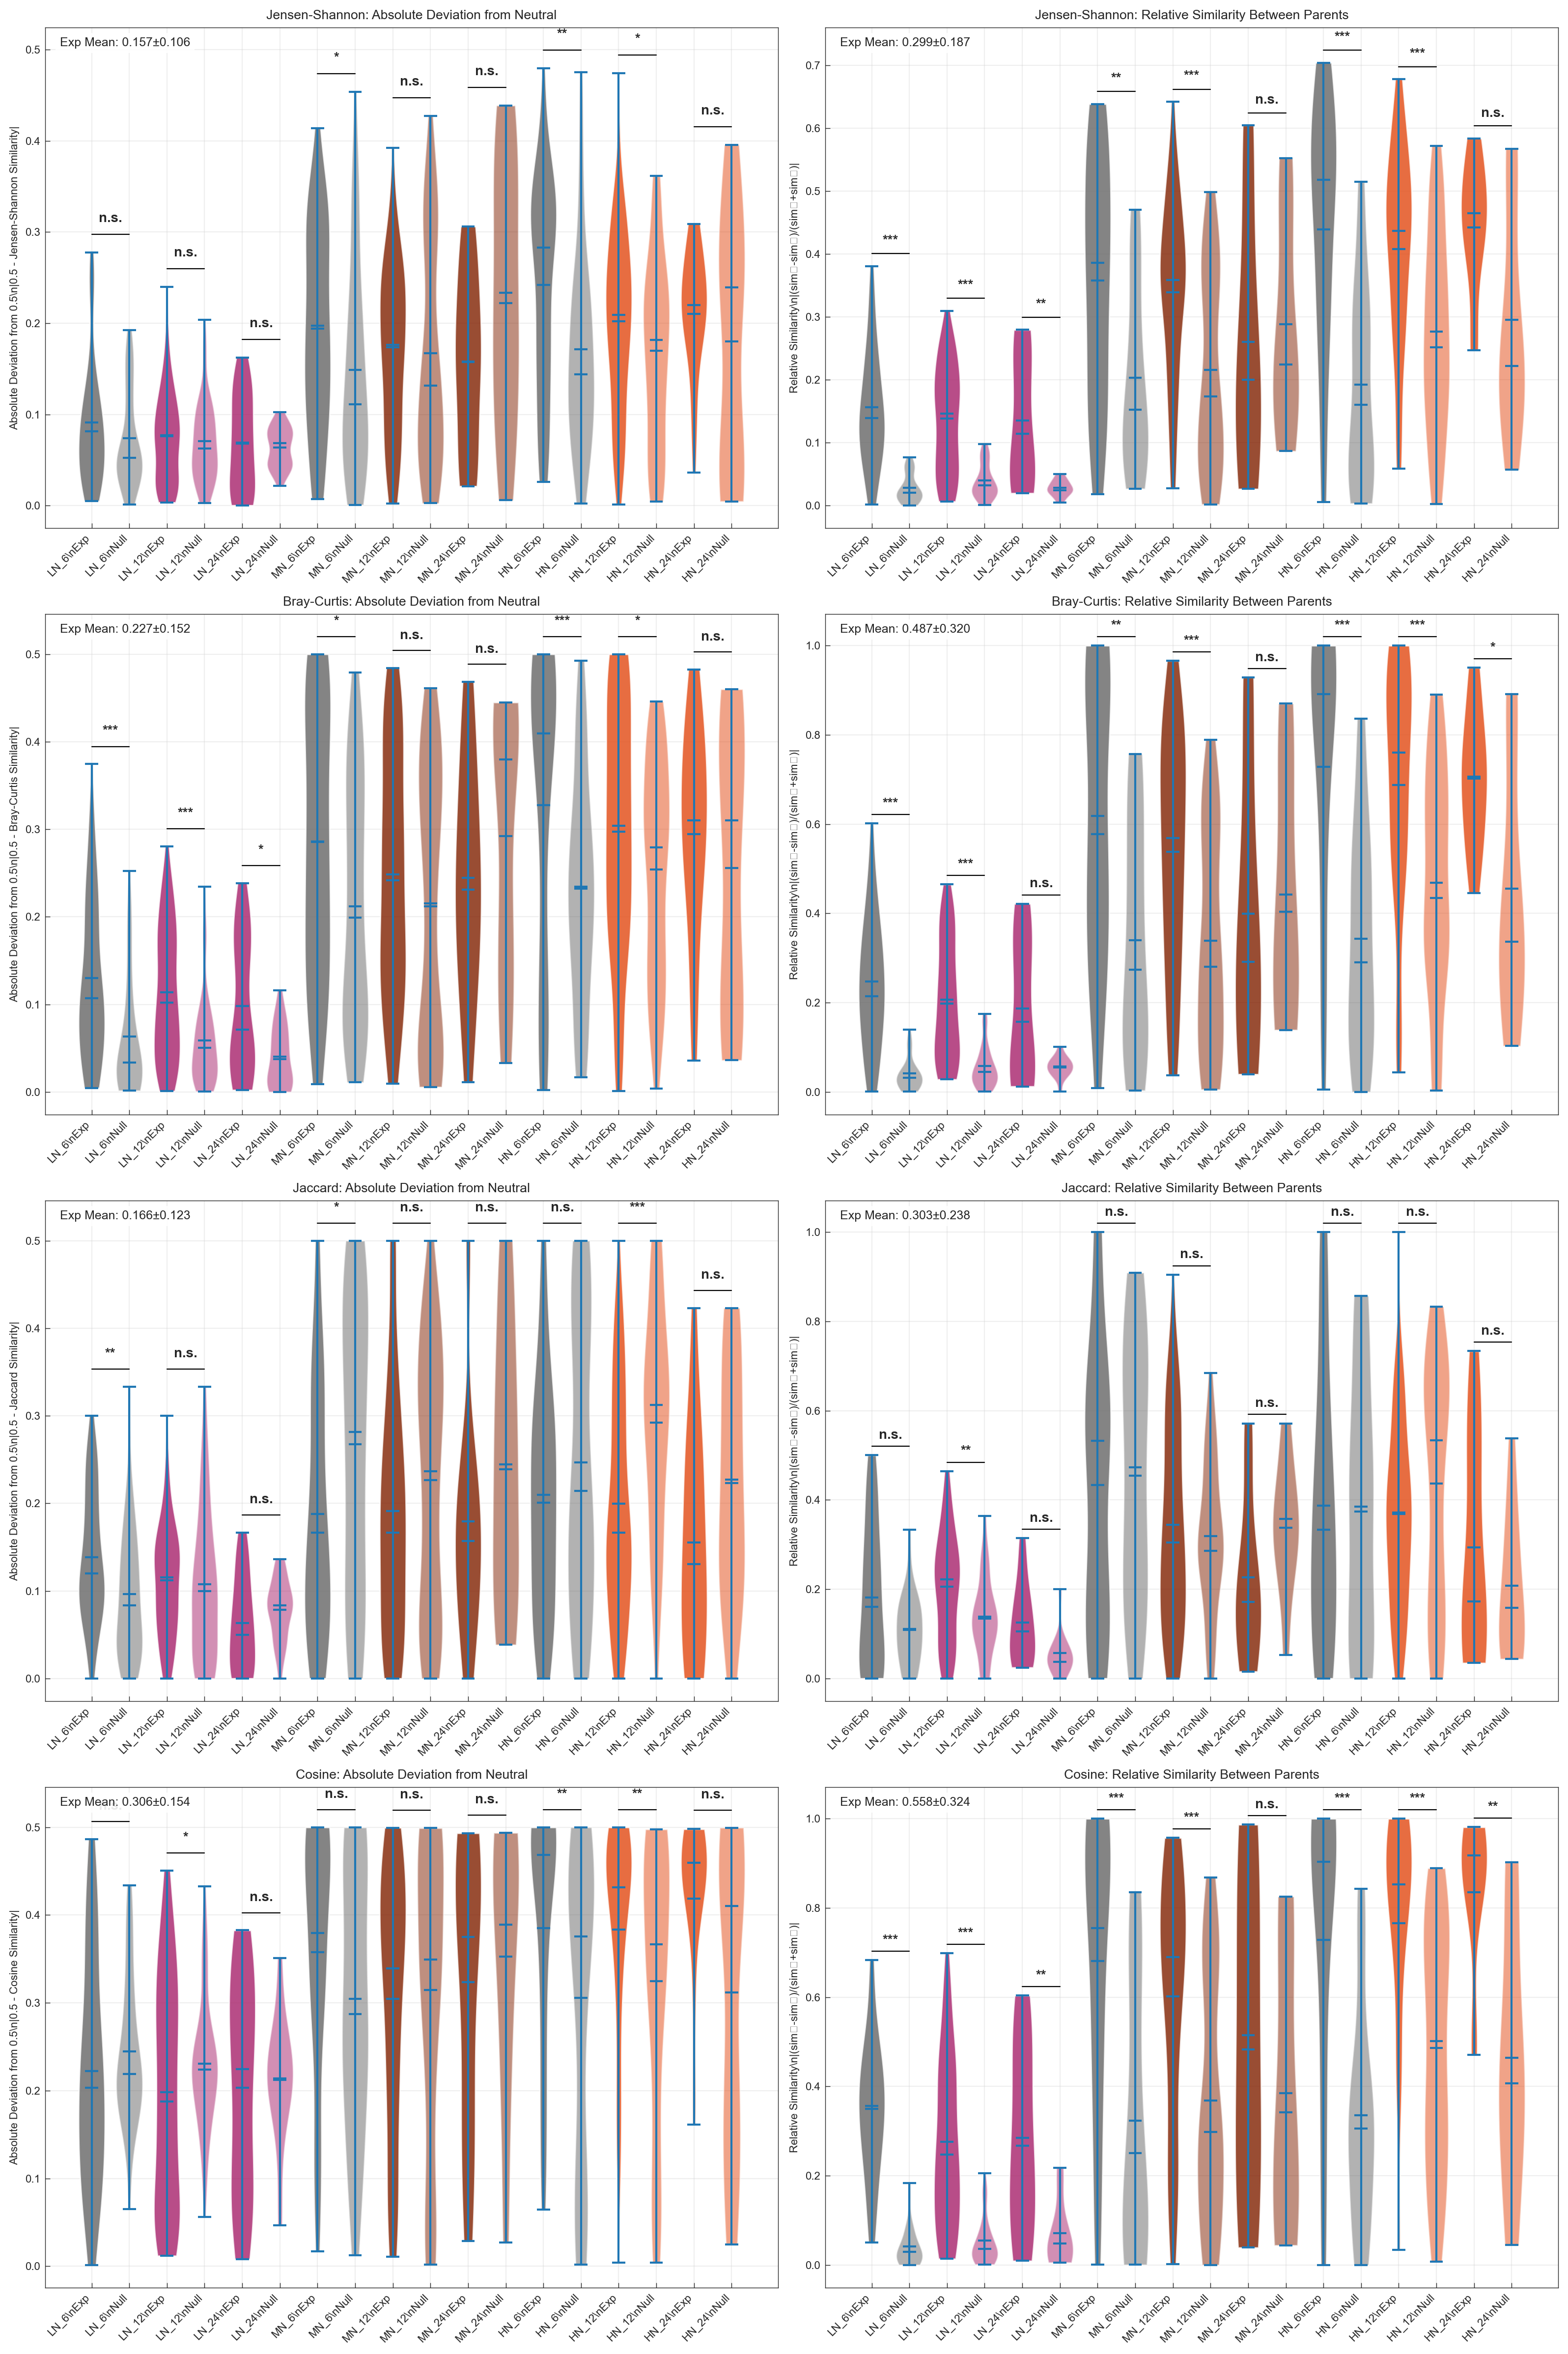

\n================================================================================
CREATING ENHANCED SUMMARY TABLE...
\n========================================================================================================================
SUMMARY TABLE: ABSOLUTE DEVIATION AND RELATIVE SIMILARITY
Nutrient         Metric Exp_Abs_Dev_Mean Exp_Abs_Dev_Std Null_Abs_Dev_Mean Null_Abs_Dev_Std Abs_Dev_Difference Exp_Rel_Sim_Mean Exp_Rel_Sim_Std Null_Rel_Sim_Mean Null_Rel_Sim_Std Rel_Sim_Difference  N_Samples_Abs  N_Samples_Rel
    LN_6 Jensen-Shannon           0.0912          0.0705            0.0738           0.0527            +0.0174           0.1561          0.0933            0.0284           0.0224            +0.1277             52             26
    LN_6    Bray-Curtis           0.1302          0.0924            0.0632           0.0662            +0.0670           0.2478          0.1475            0.0415           0.0358            +0.2063             52             26
    LN_6        J

In [22]:
# =============================================================================
# ENHANCED SIMILARITY ANALYSIS: MERGED PARENTS + ABSOLUTE & RELATIVE METRICS
# =============================================================================

def calculate_merged_similarity_metrics(results_dict):
    """
    Merge Parent1 and Parent2 data and calculate absolute and relative similarity metrics.
    
    Returns:
    - merged_results: Dictionary with merged data and new metrics
    """
    print("=" * 80)
    print("CALCULATING MERGED SIMILARITY METRICS")
    print("=" * 80)
    
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc',
        'Jaccard': 'jaccard',
        'Cosine': 'cosine'
    }
    
    merged_results = {}
    
    for nutrient in results_dict.keys():
        print(f"\\nProcessing {nutrient}...")
        
        merged_results[nutrient] = {
            'experimental_merged': {metric_code: [] for metric_code in similarity_metrics.values()},
            'null_model_merged': {metric_code: [] for metric_code in similarity_metrics.values()},
            'experimental_absolute_deviation': {metric_code: [] for metric_code in similarity_metrics.values()},
            'null_model_absolute_deviation': {metric_code: [] for metric_code in similarity_metrics.values()},
            'experimental_relative_similarity': {metric_code: [] for metric_code in similarity_metrics.values()},
            'null_model_relative_similarity': {metric_code: [] for metric_code in similarity_metrics.values()}
        }
        
        for metric_name, metric_code in similarity_metrics.items():
            # Get data for both parent comparisons
            exp_c1_mix = results_dict[nutrient]['experimental_similarities'][metric_code]['c1_mix']
            exp_c2_mix = results_dict[nutrient]['experimental_similarities'][metric_code]['c2_mix']
            null_c1_mix = results_dict[nutrient]['null_model_similarities'][metric_code]['c1_mix']
            null_c2_mix = results_dict[nutrient]['null_model_similarities'][metric_code]['c2_mix']
            
            if exp_c1_mix and exp_c2_mix and null_c1_mix and null_c2_mix:
                # Ensure equal length for proper pairing
                min_exp_len = min(len(exp_c1_mix), len(exp_c2_mix))
                min_null_len = min(len(null_c1_mix), len(null_c2_mix))
                
                exp_c1_mix = exp_c1_mix[:min_exp_len]
                exp_c2_mix = exp_c2_mix[:min_exp_len]
                null_c1_mix = null_c1_mix[:min_null_len]
                null_c2_mix = null_c2_mix[:min_null_len]
                
                # 1. MERGED DATA: Combine Parent1 and Parent2 (order doesn't matter)
                exp_merged = exp_c1_mix + exp_c2_mix
                null_merged = null_c1_mix + null_c2_mix
                
                merged_results[nutrient]['experimental_merged'][metric_code] = exp_merged
                merged_results[nutrient]['null_model_merged'][metric_code] = null_merged
                
                # 2. ABSOLUTE DEVIATION FROM 0.5: abs(0.5 - similarity)
                exp_abs_dev = [abs(0.5 - sim) for sim in exp_merged]
                null_abs_dev = [abs(0.5 - sim) for sim in null_merged]
                
                merged_results[nutrient]['experimental_absolute_deviation'][metric_code] = exp_abs_dev
                merged_results[nutrient]['null_model_absolute_deviation'][metric_code] = null_abs_dev
                
                # 3. RELATIVE SIMILARITY: abs((sim_to_1 - sim_to_2)/(sim_to_1 + sim_to_2))
                exp_rel_sim = []
                null_rel_sim = []
                
                # Calculate relative similarity for experimental data
                for i in range(min_exp_len):
                    sim1, sim2 = exp_c1_mix[i], exp_c2_mix[i]
                    if (sim1 + sim2) != 0:  # Avoid division by zero
                        rel_sim = abs((sim1 - sim2) / (sim1 + sim2))
                        exp_rel_sim.append(rel_sim)
                
                # Calculate relative similarity for null model data
                for i in range(min_null_len):
                    sim1, sim2 = null_c1_mix[i], null_c2_mix[i]
                    if (sim1 + sim2) != 0:  # Avoid division by zero
                        rel_sim = abs((sim1 - sim2) / (sim1 + sim2))
                        null_rel_sim.append(rel_sim)
                
                merged_results[nutrient]['experimental_relative_similarity'][metric_code] = exp_rel_sim
                merged_results[nutrient]['null_model_relative_similarity'][metric_code] = null_rel_sim
                
                # Print summary statistics
                print(f"  {metric_name}:")
                print(f"    Merged samples: Exp={len(exp_merged)}, Null={len(null_merged)}")
                print(f"    Abs deviation: Exp={np.mean(exp_abs_dev):.3f}±{np.std(exp_abs_dev):.3f}, Null={np.mean(null_abs_dev):.3f}±{np.std(null_abs_dev):.3f}")
                if exp_rel_sim and null_rel_sim:
                    print(f"    Rel similarity: Exp={np.mean(exp_rel_sim):.3f}±{np.std(exp_rel_sim):.3f}, Null={np.mean(null_rel_sim):.3f}±{np.std(null_rel_sim):.3f}")
    
    return merged_results


def plot_absolute_and_relative_similarity(merged_results, save_figures=True):
    """
    Create two-panel plots: Absolute deviation (left) and Relative similarity (right).
    """
    import matplotlib.pyplot as plt
    from scipy import stats
    
    # Define colors for nutrients
    nutrient_colors = {
        'LN_12': '#A7216A',   # Low Nitrogen - magenta
        'LN_24': '#A7216A',   
        'MN_12': '#802000',   # Medium Nitrogen - dark red  
        'MN_24': '#802000',   
        'HN_12': '#E24912',   # High Nitrogen - orange-red
        'HN_24': '#E24912'    
    }
    
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc',
        'Jaccard': 'jaccard',
        'Cosine': 'cosine'
    }
    
    available_nutrients = list(merged_results.keys())
    n_metrics = len(similarity_metrics)
    
    # Create figure with 2 columns (absolute deviation, relative similarity)
    fig, axes = plt.subplots(n_metrics, 2, figsize=(16, 6*n_metrics), facecolor='white')
    
    if n_metrics == 1:
        axes = axes.reshape(1, -1)
    
    print(f"Creating absolute deviation and relative similarity plots for {len(available_nutrients)} nutrients...")
    
    for i, (metric_name, metric_code) in enumerate(similarity_metrics.items()):
        
        # LEFT PANEL: ABSOLUTE DEVIATION FROM 0.5
        ax_abs = axes[i, 0]
        
        # Collect absolute deviation data
        abs_plot_data = []
        abs_plot_labels = []
        abs_plot_colors = []
        
        for nutrient in available_nutrients:
            exp_abs_dev = merged_results[nutrient]['experimental_absolute_deviation'][metric_code]
            null_abs_dev = merged_results[nutrient]['null_model_absolute_deviation'][metric_code]
            
            if exp_abs_dev and null_abs_dev and len(exp_abs_dev) > 5:
                abs_plot_data.extend([exp_abs_dev, null_abs_dev])
                abs_plot_labels.extend([f'{nutrient}\\nExp', f'{nutrient}\\nNull'])
                
                base_color = nutrient_colors.get(nutrient, '#666666')
                abs_plot_colors.extend([base_color, base_color])
        
        if abs_plot_data:
            # Create violin plot for absolute deviation
            parts = ax_abs.violinplot(abs_plot_data, range(1, len(abs_plot_data)+1), 
                                    widths=0.7, showmeans=True, showmedians=True)
            
            # Color the violins
            for k, pc in enumerate(parts['bodies']):
                color = abs_plot_colors[k] if k < len(abs_plot_colors) else '#666666'
                alpha = 0.8 if k % 2 == 0 else 0.5
                pc.set_facecolor(color)
                pc.set_alpha(alpha)
            
            # Add statistical significance tests
            for k in range(0, len(abs_plot_data), 2):
                if k+1 < len(abs_plot_data):
                    exp_data = abs_plot_data[k]
                    null_data = abs_plot_data[k+1]
                    
                    try:
                        statistic, p_value = stats.mannwhitneyu(exp_data, null_data, alternative='two-sided')
                        
                        if p_value < 0.001:
                            sig_text = '***'
                        elif p_value < 0.01:
                            sig_text = '**'
                        elif p_value < 0.05:
                            sig_text = '*'
                        else:
                            sig_text = 'n.s.'
                        
                        # Add significance annotation
                        y_max = max(max(exp_data), max(null_data))
                        y_pos = y_max + 0.02
                        x1, x2 = k+1, k+2
                        ax_abs.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=0.8)
                        ax_abs.text((x1+x2)/2, y_pos + 0.01, sig_text, ha='center', va='bottom', 
                                   fontsize=10, fontweight='bold')
                        
                    except Exception:
                        continue
            
            ax_abs.set_xticks(range(1, len(abs_plot_labels)+1))
            ax_abs.set_xticklabels(abs_plot_labels, rotation=45, ha='right')
            ax_abs.set_ylabel(f'Absolute Deviation from 0.5\\n|0.5 - {metric_name} Similarity|')
            ax_abs.set_title(f'{metric_name}: Absolute Deviation from Neutral')
            ax_abs.grid(True, alpha=0.3)
            
            # Add summary statistics
            all_exp_abs = []
            for k in range(0, len(abs_plot_data), 2):
                all_exp_abs.extend(abs_plot_data[k])
            
            if all_exp_abs:
                mean_abs = np.mean(all_exp_abs)
                std_abs = np.std(all_exp_abs)
                ax_abs.text(0.02, 0.98, f'Exp Mean: {mean_abs:.3f}±{std_abs:.3f}', 
                           transform=ax_abs.transAxes, va='top', ha='left', fontsize=9,
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        else:
            ax_abs.text(0.5, 0.5, 'No Data Available', ha='center', va='center',
                       transform=ax_abs.transAxes, fontsize=12)
            ax_abs.set_title(f'{metric_name}: Absolute Deviation')
        
        # RIGHT PANEL: RELATIVE SIMILARITY
        ax_rel = axes[i, 1]
        
        # Collect relative similarity data
        rel_plot_data = []
        rel_plot_labels = []
        rel_plot_colors = []
        
        for nutrient in available_nutrients:
            exp_rel_sim = merged_results[nutrient]['experimental_relative_similarity'][metric_code]
            null_rel_sim = merged_results[nutrient]['null_model_relative_similarity'][metric_code]
            
            if exp_rel_sim and null_rel_sim and len(exp_rel_sim) > 5:
                rel_plot_data.extend([exp_rel_sim, null_rel_sim])
                rel_plot_labels.extend([f'{nutrient}\\nExp', f'{nutrient}\\nNull'])
                
                base_color = nutrient_colors.get(nutrient, '#666666')
                rel_plot_colors.extend([base_color, base_color])
        
        if rel_plot_data:
            # Create violin plot for relative similarity
            parts = ax_rel.violinplot(rel_plot_data, range(1, len(rel_plot_data)+1), 
                                    widths=0.7, showmeans=True, showmedians=True)
            
            # Color the violins
            for k, pc in enumerate(parts['bodies']):
                color = rel_plot_colors[k] if k < len(rel_plot_colors) else '#666666'
                alpha = 0.8 if k % 2 == 0 else 0.5
                pc.set_facecolor(color)
                pc.set_alpha(alpha)
            
            # Add statistical significance tests
            for k in range(0, len(rel_plot_data), 2):
                if k+1 < len(rel_plot_data):
                    exp_data = rel_plot_data[k]
                    null_data = rel_plot_data[k+1]
                    
                    try:
                        statistic, p_value = stats.mannwhitneyu(exp_data, null_data, alternative='two-sided')
                        
                        if p_value < 0.001:
                            sig_text = '***'
                        elif p_value < 0.01:
                            sig_text = '**'
                        elif p_value < 0.05:
                            sig_text = '*'
                        else:
                            sig_text = 'n.s.'
                        
                        # Add significance annotation
                        y_max = max(max(exp_data), max(null_data))
                        y_pos = y_max + 0.02
                        x1, x2 = k+1, k+2
                        ax_rel.plot([x1, x2], [y_pos, y_pos], 'k-', linewidth=0.8)
                        ax_rel.text((x1+x2)/2, y_pos + 0.01, sig_text, ha='center', va='bottom', 
                                   fontsize=10, fontweight='bold')
                        
                    except Exception:
                        continue
            
            ax_rel.set_xticks(range(1, len(rel_plot_labels)+1))
            ax_rel.set_xticklabels(rel_plot_labels, rotation=45, ha='right')
            ax_rel.set_ylabel(f'Relative Similarity\\n|(sim₁-sim₂)/(sim₁+sim₂)|')
            ax_rel.set_title(f'{metric_name}: Relative Similarity Between Parents')
            ax_rel.grid(True, alpha=0.3)
            
            # Add summary statistics
            all_exp_rel = []
            for k in range(0, len(rel_plot_data), 2):
                all_exp_rel.extend(rel_plot_data[k])
            
            if all_exp_rel:
                mean_rel = np.mean(all_exp_rel)
                std_rel = np.std(all_exp_rel)
                ax_rel.text(0.02, 0.98, f'Exp Mean: {mean_rel:.3f}±{std_rel:.3f}', 
                           transform=ax_rel.transAxes, va='top', ha='left', fontsize=9,
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
        
        else:
            ax_rel.text(0.5, 0.5, 'No Data Available', ha='center', va='center',
                       transform=ax_rel.transAxes, fontsize=12)
            ax_rel.set_title(f'{metric_name}: Relative Similarity')
    
    plt.tight_layout()
    
    if save_figures:
        plt.savefig('Figure/Absolute_and_Relative_Similarity_Analysis.svg', 
                   bbox_inches='tight', dpi=300)
        plt.savefig('Figure/Absolute_and_Relative_Similarity_Analysis.png', 
                   bbox_inches='tight', dpi=300)
        print("Absolute and relative similarity figures saved to Figure/ directory")
    
    plt.show()
    return fig


def create_combined_summary_table(merged_results):
    """
    Create a comprehensive summary table for both absolute and relative metrics.
    """
    import pandas as pd
    
    summary_data = []
    similarity_metrics = {
        'Jensen-Shannon': 'js',
        'Bray-Curtis': 'bc',
        'Jaccard': 'jaccard',
        'Cosine': 'cosine'
    }
    
    for nutrient in merged_results.keys():
        for metric_name, metric_code in similarity_metrics.items():
            
            exp_abs = merged_results[nutrient]['experimental_absolute_deviation'][metric_code]
            null_abs = merged_results[nutrient]['null_model_absolute_deviation'][metric_code]
            exp_rel = merged_results[nutrient]['experimental_relative_similarity'][metric_code]
            null_rel = merged_results[nutrient]['null_model_relative_similarity'][metric_code]
            
            if exp_abs and null_abs and exp_rel and null_rel:
                summary_data.append({
                    'Nutrient': nutrient,
                    'Metric': metric_name,
                    'Exp_Abs_Dev_Mean': f'{np.mean(exp_abs):.4f}',
                    'Exp_Abs_Dev_Std': f'{np.std(exp_abs):.4f}',
                    'Null_Abs_Dev_Mean': f'{np.mean(null_abs):.4f}',
                    'Null_Abs_Dev_Std': f'{np.std(null_abs):.4f}',
                    'Abs_Dev_Difference': f'{np.mean(exp_abs) - np.mean(null_abs):+.4f}',
                    'Exp_Rel_Sim_Mean': f'{np.mean(exp_rel):.4f}',
                    'Exp_Rel_Sim_Std': f'{np.std(exp_rel):.4f}',
                    'Null_Rel_Sim_Mean': f'{np.mean(null_rel):.4f}',
                    'Null_Rel_Sim_Std': f'{np.std(null_rel):.4f}',
                    'Rel_Sim_Difference': f'{np.mean(exp_rel) - np.mean(null_rel):+.4f}',
                    'N_Samples_Abs': len(exp_abs),
                    'N_Samples_Rel': len(exp_rel)
                })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\\n" + "="*120)
    print("SUMMARY TABLE: ABSOLUTE DEVIATION AND RELATIVE SIMILARITY")
    print("="*120)
    print(summary_df.to_string(index=False))
    
    return summary_df


# =============================================================================
# EXECUTE ENHANCED ANALYSIS
# =============================================================================

print("Starting enhanced similarity analysis with merged parents...")
print("This will:")
print("1. Merge Parent1 and Parent2 data (order doesn't matter)")
print("2. Calculate absolute deviation: |0.5 - similarity|")
print("3. Calculate relative similarity: |(sim₁-sim₂)/(sim₁+sim₂)|")
print("4. Create two-panel plots: Absolute (left) vs Relative (right)")
print()

# Calculate merged metrics
merged_similarity_results = calculate_merged_similarity_metrics(comprehensive_results)

print("\\n" + "="*80)
print("CREATING ENHANCED PLOTS...")
print("="*80)

# Create enhanced plots
enhanced_fig = plot_absolute_and_relative_similarity(merged_similarity_results, save_figures=True)

print("\\n" + "="*80)
print("CREATING ENHANCED SUMMARY TABLE...")
print("="*80)

# Create enhanced summary table
enhanced_summary = create_combined_summary_table(merged_similarity_results)

print("\\n" + "="*80)
print("ENHANCED ANALYSIS COMPLETE!")
print("="*80)
print("Key insights:")
print("• LEFT PANELS: Absolute deviation from 0.5 (higher = more deviation from random)")
print("• RIGHT PANELS: Relative similarity between parents (higher = more asymmetric preferences)")
print("• Merged Parent1+Parent2 data (doubled sample size, order doesn't matter)")
print("• Statistical significance shown with stars (*, **, ***)")
print("\\nResults stored in 'merged_similarity_results' and 'enhanced_summary' variables")

In [18]:
# =============================================================================
# ASYMMETRICITY ANALYSIS FUNCTIONS
# =============================================================================

def calculate_similarity_asymmetricity(sim1, sim2):
    """
    Calculate similarity-based asymmetricity.
    
    Formula: |sim1 - sim2| / (sim1 + sim2)
    
    Parameters:
    - sim1, sim2: Similarity values between offspring and each parent
    
    Returns:
    - asymmetricity: Value between 0 (symmetric) and 1 (completely asymmetric)
    """
    if isinstance(sim1, (list, np.ndarray)):
        sim1 = np.array(sim1)
        sim2 = np.array(sim2)
        
        # Avoid division by zero
        denominator = sim1 + sim2 + 1e-10
        asymmetricity = np.abs(sim1 - sim2) / denominator
        return asymmetricity
    else:
        # Single values
        denominator = sim1 + sim2 + 1e-10
        asymmetricity = abs(sim1 - sim2) / denominator
        return asymmetricity

def calculate_vector_asymmetricity(magA, magB):
    """
    Calculate vector decomposition-based asymmetricity.
    
    From vector_decomposition, this gives two asymmetricity values per coalescence:
    - One for magnitude A vs total
    - One for magnitude B vs total
    
    Parameters:
    - magA, magB: Magnitude values from vector decomposition
    
    Returns:
    - asymmetricity_A, asymmetricity_B: Asymmetricity for each component
    """
    if isinstance(magA, (list, np.ndarray)):
        magA = np.array(magA)
        magB = np.array(magB)
        
        total_mag = magA + magB + 1e-10
        asymmetricity_A = np.abs(magA - 0.5 * total_mag) / (0.5 * total_mag + 1e-10)
        asymmetricity_B = np.abs(magB - 0.5 * total_mag) / (0.5 * total_mag + 1e-10)
        
        return asymmetricity_A, asymmetricity_B
    else:
        total_mag = magA + magB + 1e-10
        asymmetricity_A = abs(magA - 0.5 * total_mag) / (0.5 * total_mag + 1e-10)
        asymmetricity_B = abs(magB - 0.5 * total_mag) / (0.5 * total_mag + 1e-10)
        
        return asymmetricity_A, asymmetricity_B

def calculate_diversity_asymmetricity_type1(div1_sub, div2_sub, div_mix):
    """
    Calculate diversity-based asymmetricity Type 1.
    
    Formula: |div1_sub - div2_sub| / div_mix
    
    Parameters:
    - div1_sub, div2_sub: Diversity of each subcommunity
    - div_mix: Diversity of mixed community
    
    Returns:
    - asymmetricity: Value between 0 and varies based on diversity values
    """
    if isinstance(div1_sub, (list, np.ndarray)):
        div1_sub = np.array(div1_sub)
        div2_sub = np.array(div2_sub)
        div_mix = np.array(div_mix)
        
        asymmetricity = np.abs(div1_sub - div2_sub) / (div_mix + 1e-10)
        return asymmetricity
    else:
        asymmetricity = abs(div1_sub - div2_sub) / (div_mix + 1e-10)
        return asymmetricity

def calculate_diversity_asymmetricity_type2(div1_sub, div2_sub, div_mix):
    """
    Calculate diversity-based asymmetricity Type 2.
    
    Formula: |div1_sub - div2_sub| / (div_mix - min(div1_sub, div2_sub))
    
    Parameters:
    - div1_sub, div2_sub: Diversity of each subcommunity
    - div_mix: Diversity of mixed community
    
    Returns:
    - asymmetricity: Value between 0 and varies based on diversity values
    """
    if isinstance(div1_sub, (list, np.ndarray)):
        div1_sub = np.array(div1_sub)
        div2_sub = np.array(div2_sub)
        div_mix = np.array(div_mix)
        
        min_div = np.minimum(div1_sub, div2_sub)
        denominator = div_mix - min_div + 1e-10
        asymmetricity = np.abs(div1_sub - div2_sub) / denominator
        return asymmetricity
    else:
        min_div = min(div1_sub, div2_sub)
        denominator = div_mix - min_div + 1e-10
        asymmetricity = abs(div1_sub - div2_sub) / denominator
        return asymmetricity

def calculate_all_asymmetricities(c1, c2, c_mix, use_diversity_metrics=['richness', 'shannon', 'simpson']):
    """
    Calculate all types of asymmetricity for a single coalescence event.
    
    Parameters:
    - c1, c2: Parent community composition vectors
    - c_mix: Mixed community composition vector
    - use_diversity_metrics: List of diversity metrics to calculate
    
    Returns:
    - asymmetricities: Dictionary containing all asymmetricity values
    """
    asymmetricities = {
        'similarity_based': {},
        'vector_based': {},
        'diversity_based_type1': {},
        'diversity_based_type2': {}
    }
    
    # 1. Similarity-based asymmetricity
    similarity_metrics = ['jensen_shannon', 'bray_curtis', 'jaccard', 'cosine']
    
    for metric in similarity_metrics:
        if metric == 'jensen_shannon':
            sim1 = jensen_shannon_similarity(c_mix, c1)
            sim2 = jensen_shannon_similarity(c_mix, c2)
        elif metric == 'bray_curtis':
            sim1 = bray_curtis_similarity(c_mix, c1)
            sim2 = bray_curtis_similarity(c_mix, c2)
        elif metric == 'jaccard':
            sim1 = jaccard_similarity(c_mix, c1)
            sim2 = jaccard_similarity(c_mix, c2)
        elif metric == 'cosine':
            # Calculate cosine similarity
            c1_norm = c1 / (np.linalg.norm(c1) + 1e-10)
            c2_norm = c2 / (np.linalg.norm(c2) + 1e-10)
            c_mix_norm = c_mix / (np.linalg.norm(c_mix) + 1e-10)
            sim1 = np.dot(c_mix_norm, c1_norm)
            sim2 = np.dot(c_mix_norm, c2_norm)
        
        asymmetricities['similarity_based'][metric] = calculate_similarity_asymmetricity(sim1, sim2)
    
    # 2. Vector-based asymmetricity
    magA, magB, magC = metric_VectorDecomposition_onlyPositive(c1, c2, c_mix)
    asym_A, asym_B = calculate_vector_asymmetricity(magA, magB)
    asymmetricities['vector_based']['magnitude_A'] = asym_A
    asymmetricities['vector_based']['magnitude_B'] = asym_B
    
    # 3. Diversity-based asymmetricity
    for div_metric in use_diversity_metrics:
        if div_metric == 'richness':
            div1 = np.sum(c1 > 1e-6)
            div2 = np.sum(c2 > 1e-6)
            div_mix = np.sum(c_mix > 1e-6)
        elif div_metric == 'shannon':
            # Shannon diversity
            c1_norm = c1 / (np.sum(c1) + 1e-10)
            c1_norm = c1_norm[c1_norm > 0]
            div1 = -np.sum(c1_norm * np.log(c1_norm)) if len(c1_norm) > 0 else 0
            
            c2_norm = c2 / (np.sum(c2) + 1e-10)
            c2_norm = c2_norm[c2_norm > 0]
            div2 = -np.sum(c2_norm * np.log(c2_norm)) if len(c2_norm) > 0 else 0
            
            c_mix_norm = c_mix / (np.sum(c_mix) + 1e-10)
            c_mix_norm = c_mix_norm[c_mix_norm > 0]
            div_mix = -np.sum(c_mix_norm * np.log(c_mix_norm)) if len(c_mix_norm) > 0 else 0
        elif div_metric == 'simpson':
            # Simpson diversity (inverse)
            c1_norm = c1 / (np.sum(c1) + 1e-10)
            div1 = 1 / (np.sum(c1_norm**2) + 1e-10)
            
            c2_norm = c2 / (np.sum(c2) + 1e-10)
            div2 = 1 / (np.sum(c2_norm**2) + 1e-10)
            
            c_mix_norm = c_mix / (np.sum(c_mix) + 1e-10)
            div_mix = 1 / (np.sum(c_mix_norm**2) + 1e-10)
        
        asymmetricities['diversity_based_type1'][div_metric] = calculate_diversity_asymmetricity_type1(div1, div2, div_mix)
        asymmetricities['diversity_based_type2'][div_metric] = calculate_diversity_asymmetricity_type2(div1, div2, div_mix)
    
    return asymmetricities

In [19]:
def analyze_asymmetricity_across_nutrients(nutrient_conditions=['LN_12', 'MN_12', 'HN_12'], 
                                          include_null_model=False, verbose=True):
    """
    Analyze asymmetricity across different nutrient conditions.
    
    Parameters:
    - nutrient_conditions: List of nutrient conditions to analyze
    - include_null_model: Whether to generate null model comparisons (placeholder for now)
    - verbose: Whether to print progress
    
    Returns:
    - results: Dictionary containing asymmetricity results for each nutrient condition
    """
    
    print("=== COMPREHENSIVE ASYMMETRICITY ANALYSIS ===")
    print(f"Analyzing nutrient conditions: {nutrient_conditions}")
    print(f"Include null model: {include_null_model}")
    print()
    
    asymmetricity_results = {}
    
    for nutrient_condition in nutrient_conditions:
        if verbose:
            print(f"ANALYZING NUTRIENT CONDITION: {nutrient_condition}")
            print("-" * 50)
        
        # Initialize storage for this nutrient
        nutrient_results = {
            'similarity_based': {metric: [] for metric in ['jensen_shannon', 'bray_curtis', 'jaccard', 'cosine']},
            'vector_based': {'magnitude_A': [], 'magnitude_B': []},
            'diversity_based_type1': {metric: [] for metric in ['richness', 'shannon', 'simpson']},
            'diversity_based_type2': {metric: [] for metric in ['richness', 'shannon', 'simpson']},
            'null_model': None,  # Placeholder for null model results
            'processed_samples': 0,
            'failed_samples': 0
        }
        
        # Get samples for this nutrient condition
        if nutrient_condition in Syn_Coal_IDX:
            coal_indices = Syn_Coal_IDX[nutrient_condition]
            sub_indices = Syn_Sub_IDX[nutrient_condition]
        else:
            print(f"Warning: No data found for nutrient condition {nutrient_condition}")
            continue
        
        # Process each coalescence sample
        for i, mixture_sample_idx in enumerate(coal_indices):
            try:
                # Get parent samples for this mixture
                parent_samples = sub_indices[i] if i < len(sub_indices) else None
                
                if parent_samples is None or len(parent_samples) < 2:
                    nutrient_results['failed_samples'] += 1
                    continue
                
                sample_idx_1, sample_idx_2 = parent_samples[0], parent_samples[1]
                
                # Get composition vectors (skip first 4 columns which are metadata)
                c_1 = Communities_data.iloc[sample_idx_1, 4:].values.astype(float)
                c_2 = Communities_data.iloc[sample_idx_2, 4:].values.astype(float)
                c_mix = Communities_data.iloc[mixture_sample_idx, 4:].values.astype(float)
                
                # Apply filtering and normalization
                c_1 = c_1 * (c_1 > 1e-4)
                c_2 = c_2 * (c_2 > 1e-4)
                c_mix = c_mix * (c_mix > 1e-4)
                
                c_1 = c_1 / (np.sum(c_1) + 1e-9)
                c_2 = c_2 / (np.sum(c_2) + 1e-9)
                c_mix = c_mix / (np.sum(c_mix) + 1e-9)
                
                # Calculate all asymmetricities
                asymmetricities = calculate_all_asymmetricities(c_1, c_2, c_mix)
                
                # Store results
                for metric, value in asymmetricities['similarity_based'].items():
                    nutrient_results['similarity_based'][metric].append(value)
                
                for component, value in asymmetricities['vector_based'].items():
                    nutrient_results['vector_based'][component].append(value)
                
                for metric, value in asymmetricities['diversity_based_type1'].items():
                    nutrient_results['diversity_based_type1'][metric].append(value)
                
                for metric, value in asymmetricities['diversity_based_type2'].items():
                    nutrient_results['diversity_based_type2'][metric].append(value)
                
                nutrient_results['processed_samples'] += 1
                
            except Exception as e:
                nutrient_results['failed_samples'] += 1
                if i < 5:  # Only print first few errors
                    print(f"    Error processing sample {mixture_sample_idx}: {e}")
        
        # Store results for this nutrient
        asymmetricity_results[nutrient_condition] = nutrient_results
        
        if verbose:
            print(f"SUMMARY FOR {nutrient_condition}:")
            print(f"  Successfully processed: {nutrient_results['processed_samples']} samples")
            print(f"  Failed samples: {nutrient_results['failed_samples']} samples")
            
            # Print asymmetricity statistics
            print("  Asymmetricity Statistics:")
            
            # Similarity-based
            print("    Similarity-based:")
            for metric, values in nutrient_results['similarity_based'].items():
                if values:
                    mean_val = np.mean(values)
                    std_val = np.std(values)
                    print(f"      {metric}: {mean_val:.3f} ± {std_val:.3f} (n={len(values)})")
            
            # Vector-based
            print("    Vector-based:")
            for component, values in nutrient_results['vector_based'].items():
                if values:
                    mean_val = np.mean(values)
                    std_val = np.std(values)
                    print(f"      {component}: {mean_val:.3f} ± {std_val:.3f} (n={len(values)})")
            
            # Diversity-based
            print("    Diversity-based Type 1:")
            for metric, values in nutrient_results['diversity_based_type1'].items():
                if values:
                    mean_val = np.mean(values)
                    std_val = np.std(values)
                    print(f"      {metric}: {mean_val:.3f} ± {std_val:.3f} (n={len(values)})")
            
            print("    Diversity-based Type 2:")
            for metric, values in nutrient_results['diversity_based_type2'].items():
                if values:
                    mean_val = np.mean(values)
                    std_val = np.std(values)
                    print(f"      {metric}: {mean_val:.3f} ± {std_val:.3f} (n={len(values)})")
            
            print()
    
    return asymmetricity_results

In [20]:
def plot_asymmetricity_comparison(asymmetricity_results, asymmetricity_type='similarity_based', 
                                  save_figures=True, figure_dir='./figures'):
    """
    Create comprehensive plots for asymmetricity analysis.
    
    Parameters:
    - asymmetricity_results: Results from analyze_asymmetricity_across_nutrients()
    - asymmetricity_type: 'similarity_based', 'vector_based', 'diversity_based_type1', or 'diversity_based_type2'
    - save_figures: Whether to save the figures
    - figure_dir: Directory to save figures
    
    Returns:
    - fig: Matplotlib figure object
    """
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy import stats
    import os
    
    # Create figure directory if it doesn't exist
    if save_figures and not os.path.exists(figure_dir):
        os.makedirs(figure_dir)
    
    # Define colors for nutrients
    nutrient_colors = {
        'LN_12': '#A7216A',   # Low Nitrogen - magenta
        'MN_12': '#802000',   # Medium Nitrogen - dark red
        'HN_12': '#E24912'    # High Nitrogen - orange-red
    }
    
    # Get available nutrients and metrics
    available_nutrients = list(asymmetricity_results.keys())
    
    if asymmetricity_type not in ['similarity_based', 'vector_based', 'diversity_based_type1', 'diversity_based_type2']:
        raise ValueError(f"Unknown asymmetricity type: {asymmetricity_type}")
    
    # Get metrics for this asymmetricity type
    if asymmetricity_type == 'similarity_based':
        metrics = ['jensen_shannon', 'bray_curtis', 'jaccard', 'cosine']
        metric_labels = ['Jensen-Shannon', 'Bray-Curtis', 'Jaccard', 'Cosine']
    elif asymmetricity_type == 'vector_based':
        metrics = ['magnitude_A', 'magnitude_B']
        metric_labels = ['Magnitude A', 'Magnitude B']
    elif asymmetricity_type in ['diversity_based_type1', 'diversity_based_type2']:
        metrics = ['richness', 'shannon', 'simpson']
        metric_labels = ['Richness', 'Shannon', 'Simpson']
    
    # Create subplots
    n_metrics = len(metrics)
    n_nutrients = len(available_nutrients)
    
    fig, axes = plt.subplots(1, n_metrics, figsize=(5*n_metrics, 6), facecolor='white')
    
    if n_metrics == 1:
        axes = [axes]
    
    plt.suptitle(f'Asymmetricity Analysis: {asymmetricity_type.replace("_", " ").title()}', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    for i, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[i]
        
        # Collect data for this metric
        plot_data = []
        plot_labels = []
        plot_colors = []
        
        for nutrient in available_nutrients:
            if nutrient in asymmetricity_results:
                values = asymmetricity_results[nutrient][asymmetricity_type][metric]
                
                if values and len(values) > 2:  # Minimum 3 samples
                    plot_data.append(values)
                    plot_labels.append(nutrient)
                    plot_colors.append(nutrient_colors.get(nutrient, '#666666'))
        
        if plot_data:
            # Create box plot
            box_plots = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True, 
                                  notch=True, showmeans=True)
            
            # Color the boxes
            for patch, color in zip(box_plots['boxes'], plot_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # Overlay violin plot for density
            violin_parts = ax.violinplot(plot_data, positions=range(1, len(plot_data)+1), 
                                       showmeans=False, showextrema=False, alpha=0.3)
            
            for j, (vp, color) in enumerate(zip(violin_parts['bodies'], plot_colors)):
                vp.set_facecolor(color)
                vp.set_alpha(0.3)
            
            # Add individual points with jitter
            for j, (values, color) in enumerate(zip(plot_data, plot_colors)):
                y = values
                x = np.random.normal(j+1, 0.04, size=len(y))
                ax.scatter(x, y, alpha=0.6, s=20, color=color, edgecolors='black', linewidth=0.5)
        
        ax.set_title(f'{metric_label}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Nutrient Condition', fontsize=12)
        ax.set_ylabel('Asymmetricity', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, None)  # Start from 0 since asymmetricity is always positive
        
        # Add sample size annotations
        for j, (nutrient, values) in enumerate(zip(available_nutrients, plot_data)):
            if values:
                ax.text(j+1, ax.get_ylim()[1]*0.95, f'n={len(values)}', 
                       ha='center', va='top', fontsize=10, 
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
        
        # Statistical comparisons
        if len(plot_data) >= 2:
            # Perform pairwise statistical tests
            for j in range(len(plot_data)):
                for k in range(j+1, len(plot_data)):
                    try:
                        statistic, pvalue = stats.mannwhitneyu(plot_data[j], plot_data[k], alternative='two-sided')
                        sig_text = '***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'n.s.'
                        
                        # Add significance annotation
                        y_pos = ax.get_ylim()[1] * (0.85 - 0.05 * (j + k))
                        ax.text((j+1 + k+1) / 2, y_pos, sig_text, ha='center', va='center',
                               bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.5),
                               fontsize=8)
                    except Exception as e:
                        print(f"Statistical test failed for {plot_labels[j]} vs {plot_labels[k]}: {e}")
    
    plt.tight_layout()
    
    if save_figures:
        filename = f'asymmetricity_{asymmetricity_type}.png'
        filepath = os.path.join(figure_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"Figure saved: {filepath}")
    
    plt.show()
    
    return fig

def plot_all_asymmetricities(asymmetricity_results, save_figures=True, figure_dir='./figures'):
    """
    Create plots for all asymmetricity types.
    
    Parameters:
    - asymmetricity_results: Results from analyze_asymmetricity_across_nutrients()
    - save_figures: Whether to save the figures
    - figure_dir: Directory to save figures
    
    Returns:
    - figures: Dictionary containing all figure objects
    """
    
    asymmetricity_types = ['similarity_based', 'vector_based', 'diversity_based_type1', 'diversity_based_type2']
    figures = {}
    
    print("Creating asymmetricity plots for all types...")
    
    for asym_type in asymmetricity_types:
        print(f"  Plotting {asym_type}...")
        try:
            fig = plot_asymmetricity_comparison(asymmetricity_results, asym_type, save_figures, figure_dir)
            figures[asym_type] = fig
        except Exception as e:
            print(f"    Error plotting {asym_type}: {e}")
    
    return figures

def create_asymmetricity_summary_table(asymmetricity_results):
    """
    Create a summary table of asymmetricity statistics.
    
    Parameters:
    - asymmetricity_results: Results from analyze_asymmetricity_across_nutrients()
    
    Returns:
    - summary_df: Pandas DataFrame with summary statistics
    """
    
    import pandas as pd
    
    summary_data = []
    
    for nutrient in asymmetricity_results.keys():
        for asym_type in ['similarity_based', 'vector_based', 'diversity_based_type1', 'diversity_based_type2']:
            for metric, values in asymmetricity_results[nutrient][asym_type].items():
                if values:
                    summary_data.append({
                        'Nutrient': nutrient,
                        'Asymmetricity_Type': asym_type,
                        'Metric': metric,
                        'Mean': np.mean(values),
                        'Std': np.std(values),
                        'Median': np.median(values),
                        'Q25': np.percentile(values, 25),
                        'Q75': np.percentile(values, 75),
                        'Min': np.min(values),
                        'Max': np.max(values),
                        'N_Samples': len(values)
                    })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Format numeric columns
    numeric_cols = ['Mean', 'Std', 'Median', 'Q25', 'Q75', 'Min', 'Max']
    for col in numeric_cols:
        summary_df[col] = summary_df[col].round(4)
    
    return summary_df

In [17]:
# =============================================================================
# ASYMMETRICITY ANALYSIS EXECUTION
# =============================================================================

print("Starting comprehensive asymmetricity analysis...")
print("This will analyze three types of asymmetricity:")
print("1. Similarity-based: |sim1-sim2|/(sim1+sim2)")
print("2. Vector-based: Magnitude asymmetricity from vector decomposition")
print("3. Diversity-based: Two types using diversity metrics")
print()

# Run the comprehensive asymmetricity analysis
asymmetricity_results = analyze_asymmetricity_across_nutrients(
    nutrient_conditions=['LN_12', 'MN_12', 'HN_12'],
    include_null_model=False,  # Set to True when null models are implemented
    verbose=True
)

Starting comprehensive asymmetricity analysis...
This will analyze three types of asymmetricity:
1. Similarity-based: |sim1-sim2|/(sim1+sim2)
2. Vector-based: Magnitude asymmetricity from vector decomposition
3. Diversity-based: Two types using diversity metrics



NameError: name 'analyze_asymmetricity_across_nutrients' is not defined

In [ ]:
# =============================================================================
# ASYMMETRICITY PLOTTING
# =============================================================================

print("Creating asymmetricity plots...")

# Create plots for all asymmetricity types
figures = plot_all_asymmetricities(
    asymmetricity_results, 
    save_figures=True, 
    figure_dir='./asymmetricity_figures'
)

print("Asymmetricity plots completed!")
print()

# Create summary table
print("Creating asymmetricity summary table...")
summary_table = create_asymmetricity_summary_table(asymmetricity_results)

print("ASYMMETRICITY SUMMARY TABLE:")
print("=" * 80)
print(summary_table.to_string(index=False))
print()

# Display key insights
print("KEY INSIGHTS:")
print("=" * 40)

for nutrient in ['LN_12', 'MN_12', 'HN_12']:
    if nutrient in asymmetricity_results:
        print(f"\n{nutrient} (n={asymmetricity_results[nutrient]['processed_samples']} samples):")
        
        # Similarity-based asymmetricity
        sim_means = []
        for metric in ['jensen_shannon', 'bray_curtis', 'jaccard', 'cosine']:
            values = asymmetricity_results[nutrient]['similarity_based'][metric]
            if values:
                sim_means.append(np.mean(values))
        
        if sim_means:
            avg_sim_asym = np.mean(sim_means)
            print(f"  Average similarity asymmetricity: {avg_sim_asym:.3f}")
        
        # Vector-based asymmetricity
        mag_a_values = asymmetricity_results[nutrient]['vector_based']['magnitude_A']
        mag_b_values = asymmetricity_results[nutrient]['vector_based']['magnitude_B']
        
        if mag_a_values and mag_b_values:
            avg_vec_asym = (np.mean(mag_a_values) + np.mean(mag_b_values)) / 2
            print(f"  Average vector asymmetricity: {avg_vec_asym:.3f}")
        
        # Diversity-based asymmetricity (type 1)
        div_means_t1 = []
        for metric in ['richness', 'shannon', 'simpson']:
            values = asymmetricity_results[nutrient]['diversity_based_type1'][metric]
            if values:
                div_means_t1.append(np.mean(values))
        
        if div_means_t1:
            avg_div_asym_t1 = np.mean(div_means_t1)
            print(f"  Average diversity asymmetricity (type 1): {avg_div_asym_t1:.3f}")
        
        # Diversity-based asymmetricity (type 2)
        div_means_t2 = []
        for metric in ['richness', 'shannon', 'simpson']:
            values = asymmetricity_results[nutrient]['diversity_based_type2'][metric]
            if values:
                div_means_t2.append(np.mean(values))
        
        if div_means_t2:
            avg_div_asym_t2 = np.mean(div_means_t2)
            print(f"  Average diversity asymmetricity (type 2): {avg_div_asym_t2:.3f}")

print("\nAnalysis complete! Check the generated figures for detailed visualizations.")